<h1> Proyecto de Machine learning <h1>

### Realizado por:
#### - Maria Juliana Quintero Duque
#### - Maria José Salazar Jaramillo
#### - Santiago Villegas Restrepo


## Contexto

| Problema | Tipo de tarea | Área financiera |
|---|---|---|
| **Predicción de impago de prestamos** | Clasificación binaria - multi clase | Fintech |


#Descripción de la base de datos:

Para este proyecto se utilizó la base de datos Prosper Loan Data, disponible públicamente en Kaggle. Contiene información histórica de 113,937 préstamos otorgados a través de Prosper, la primera plataforma fintech de peer-to-peer lending de Estados Unidos, con más de 7 mil millones de dólares en préstamos financiados. En este modelo de negocio, inversionistas individuales fondean préstamos a otras personas y Prosper actúa como intermediaria, evaluando el riesgo crediticio de cada solicitante y fijando las condiciones del préstamo (tasa, monto, plazo). El dominio del problema es el de riesgo de crédito (credit scoring) dentro del sector fintech.

Cada fila del dataset representa un préstamo individual, descrito por 81 variables que incluyen datos del solicitante disponibles al momento de la solicitud, así como variables asociadas al desempeño y cierre del préstamo. Esta base de datos es muy relevante porque replica una decisión de negocio real; decidir si otorgar o no un crédito, y bajo qué condiciones, minimizando la pérdida esperada por incumplimiento sin sacrificar volumen de negocio de forma innecesaria.

Este problema se plantea como un modelo de aprendizaje supervisado de clasificación multiclase. La variable de salida se construye a partir de una transformación de la columna original “LoanStatus”, que en su forma nativa trae siete categorías (Cancelled, Chargedoff, Completed, Current, Defaulted, FinalPaymentInProgress, PastDue). Dado que a la fintech no le interesa distinguir con el mismo nivel de detalle entre, por ejemplo, "Cancelled" y "Completed", sino identificar si el préstamo terminará en impago, en mora o será pagado con normalidad, que es lo que efectivamente determina la decisión de prestar y la tasa a cobrar, estas categorías se reagrupan en tres nuevas clases: “Pago cumplido”, “Mora” o “Default”.

Los préstamos cancelados se excluyen del análisis por no representar un desenlace de riesgo crediticio comparable, y los préstamos aún vigentes se excluyen del entrenamiento por tratarse de casos cuyo resultado final todavía se desconoce.

Con esta variable objetivo, el modelo busca, dado un nuevo solicitante y la información disponible al momento de la solicitud, predecir a cuál de estos tres desenlaces corresponderá el préstamo.


#Descripción de las variables

**Variable objetivo:**
**LoanStatus:** Estado original del préstamo.

-	Completed: Préstamo pagado en su totalidad
-	Current: Al día con los pagos (aún activo pero sin atraso)
-	FinalPaymentInProgress: En proceso de pago final, sin atraso
-	Past Due (todas las variantes: 1-15, 16-30, 31-60, 61-90, 91-120, >120 días)
- Atrasado pero aún no ha sido declarado en default
-	Chargedoff :La entidad castigó la deuda como pérdida
-	Defaulted: Incumplimiento formal del préstamo
-	Cancelled: Normalmente significa que el listado nunca llegó a fondearse/originarse, no refleja comportamiento de pago.

**LoanStatus_num:** es una variable multilcase en la cuál se agruparon las categorías de la variable presentada anteriormente, donde:

-	Pago cumplido = 0
-	Mora = 1
-	Default = 2

**Calificación de riesgo (Prosper):**

-	CreditGrade: Sistema de calificación de crédito usado antes del 2009
-	PorsperRating: sistema de calificación de crédito actual de la compañía. Va de 1 a 7, dónde 1 es muy riesgoso y 7 menos riesgoso.
-	ProsperRating(Alpha): sistema de calificación de crédito actual de la compañía en letras: AA significa menos riesgoso y HR más riesgoso.
-	ProsperScore: Un score interno de Prosper, de 1 a 11, calculado con un modelo propio que combina muchas variables del prestatario. A mayor número, menor riesgo
-	CreditScoreMid: es un promedio de los rangos de la calificación crediticia de los clientes (por privacidad).

**Historial crediticio:**
- OpenCreditLines: número de líneas de crédito
- OpenRevolvlinMonthPayment: pago mensual en cuentas**
- InquiriesLast6months: número de consultas de crédito en los últimos 6 meses
- TotaliInquiries: número total histórico de consultas ce crédito
- CurrentDeliquiencies: número de cuentas actualmente en mora
- Amountdeliquent: monto total en mora actualmente
- Deliquiencieslast7year: número de mora en los últimos 7 años
- Publicrecordlast10year: registros públicos negativos en los últimos 10 años
- Publicrecordslast12months: registros públicos negativos en los últimos 12 meses
- Revolvincreditbalance: saldo actual en crédito revolvente (cupo fijo).
- Bankcardutilization: % de utilización en tarjetas de crédito
- Availablebankcardcredit: cupo disponible en tarjetas de crédito
- Tradesneverdeliquient: % de cuentas que nunca han caído en mora
- Tradesopenedlast6months: número de cuentas abiertas en los últimos 6 meses
- Antiguedadcrediticia: antiguedad del historial crediticio en años

**Ingresos y deuda:**

-	DebtToincomeratio: ratio deuda/ingreso
-	IncomeRange: rango de ingreso declarado
-	Incomeverifiable: indica si el ingreso es verificable
-	Statedmonthlyincome: ingreso mensual declarado.

**Datos del préstamo:**

-	Term: plazo del préstamo en meses
-	Loanoriginalamount: monto original solicitado
-	Loanorigination: propósito del préstamo
-	Totalprosperloans: número de préstamos previos en Prosper.

**Perfil del prestatario:**

- Borrowerstate: estado de residencia del prestatario
- Occupation: ocupación declarada
- Employmentstatues: estado laboral
- Isborrowehomeowner: si el cliente es propietario de vivienda
- Currentleingroup: si pertenece a un grupo prosper
- Recommendatios: número de recomendaciones recibidas en la plataforma



In [13]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("henryokam/prosper-loan-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'prosper-loan-data' dataset.
Path to dataset files: /kaggle/input/prosper-loan-data


In [14]:
# Importaciones base
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

# ML / Preprocesamiento
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score

# Utilidades
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)
pd.set_option("display.max_columns", 100)

In [15]:
archivos = os.listdir(path)
print("Archivos encontrados:", archivos)
archivo_csv = [f for f in archivos if f.endswith(".csv")][0]
ruta_completa = os.path.join(path, archivo_csv)
df = pd.read_csv(ruta_completa)
df.head()

Archivos encontrados: ['prosperLoanData.csv']


,ListingKey,ListingNumber,ListingCreationDate,CreditGrade,Term,LoanStatus,ClosedDate,BorrowerAPR,BorrowerRate,LenderYield,EstimatedEffectiveYield,EstimatedLoss,EstimatedReturn,ProsperRating (numeric),ProsperRating (Alpha),ProsperScore,ListingCategory (numeric),BorrowerState,Occupation,EmploymentStatus,EmploymentStatusDuration,IsBorrowerHomeowner,CurrentlyInGroup,GroupKey,DateCreditPulled,CreditScoreRangeLower,CreditScoreRangeUpper,FirstRecordedCreditLine,CurrentCreditLines,OpenCreditLines,TotalCreditLinespast7years,OpenRevolvingAccounts,OpenRevolvingMonthlyPayment,InquiriesLast6Months,TotalInquiries,CurrentDelinquencies,AmountDelinquent,DelinquenciesLast7Years,PublicRecordsLast10Years,PublicRecordsLast12Months,RevolvingCreditBalance,BankcardUtilization,AvailableBankcardCredit,TotalTrades,TradesNeverDelinquent (percentage),TradesOpenedLast6Months,DebtToIncomeRatio,IncomeRange,IncomeVerifiable,StatedMonthlyIncome,LoanKey,TotalProsperLoans,TotalProsperPaymentsBilled,OnTimeProsperPayments,ProsperPaymentsLessThanOneMonthLate,ProsperPaymentsOneMonthPlusLate,ProsperPrincipalBorrowed,ProsperPrincipalOutstanding,ScorexChangeAtTimeOfListing,LoanCurrentDaysDelinquent,LoanFirstDefaultedCycleNumber,LoanMonthsSinceOrigination,LoanNumber,LoanOriginalAmount,LoanOriginationDate,LoanOriginationQuarter,MemberKey,MonthlyLoanPayment,LP_CustomerPayments,LP_CustomerPrincipalPayments,LP_InterestandFees,LP_ServiceFees,LP_CollectionFees,LP_GrossPrincipalLoss,LP_NetPrincipalLoss,LP_NonPrincipalRecoverypayments,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors
0,1021339766868145413AB3B,193129,2007-08-26 19:09:29.263000000,C,36,Completed,2009-08-14 00:00:00,0.16516,0.1580,0.1380,NaN,NaN,NaN,NaN,NaN,NaN,0,CO,Other,Self-employed,2.0,True,True,NaN,2007-08-26 18:41:46.780000000,640.0,659.0,2001-10-11 00:00:00,5.0,4.0,12.0,1,24.0,3.0,3.0,2.0,472.0,4.0,0.0,0.0,0.0,0.00,1500.0,11.0,0.81,0.0,0.17,"$25,000-49,999",True,3083.333333,E33A3400205839220442E84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,78,19141,9425,2007-09-12 00:00:00,Q3 2007,1F3E3376408759268057EDA,330.43,11396.14,9425.00,1971.14,-133.18,0.0,0.0,0.0,0.0,1.0,0,0,0.0,258
1,10273602499503308B223C1,1209647,2014-02-27 08:28:07.900000000,NaN,36,Current,NaN,0.12016,0.0920,0.0820,0.07960,0.0249,0.05470,6.0,A,7.0,2,CO,Professional,Employed,44.0,False,False,NaN,2014-02-27 08:28:14,680.0,699.0,1996-03-18 00:00:00,14.0,14.0,29.0,13,389.0,3.0,5.0,0.0,0.0,0.0,1.0,0.0,3989.0,0.21,10266.0,29.0,1.00,2.0,0.18,"$50,000-74,999",True,6125.000000,9E3B37071505919926B1D82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,0,134815,10000,2014-03-03 00:00:00,Q1 2014,1D13370546739025387B2F4,318.93,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,1.0,0,0,0.0,1
2,0EE9337825851032864889A,81716,2007-01-05 15:00:47.090000000,HR,36,Completed,2009-12-17 00:00:00,0.28269,0.2750,0.2400,NaN,NaN,NaN,NaN,NaN,NaN,0,GA,Other,Not available,NaN,False,True,783C3371218786870A73D20,2007-01-02 14:09:10.060000000,480.0,499.0,2002-07-27 00:00:00,NaN,NaN,3.0,0,0.0,0.0,1.0,1.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.06,Not displayed,True,2083.333333,6954337960046817851BCB2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,86,6466,3001,2007-01-17 00:00:00,Q1 2007,5F7033715035555618FA612,123.32,4186.63,3001.00,1185.63,-24.20,0.0,0.0,0.0,0.0,1.0,0,0,0.0,41
3,0EF5356002482715299901A,658116,2012-10-22 11:02:35.010000000,NaN,36,Current,NaN,0.12528,0.0974,0.0874,0.08490,0.0249,0.06000,6.0,A,9.0,16,GA,Skilled Labor,Employed,113.0,True,False,NaN,2012-10-22 11:02:32,800.0,819.0,1983-02-28 00:00:00,5.0,5.0,29.0,7,115.0,0.0,1.0,4.0,10056.0,14.0,0.0,0.0,1444.0,0.04,30754.0,26.0,0.76,0.0,0.15,"$25,000-49,999",True,2875.000000,A0393664465886295619C51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,16,77296,10000,2012-11-01 00:00:00,Q4 2012,9ADE356069835475068C6D2,321.45,5143.20,4091.09,1052.11,-108.01,0.0,0.0,0.0,0.0,1.0,0,0,0.0,158
4,0F023589499656230C5E3E2,909464,2013-09-14 18:38:39.097000000,NaN,36,Current,NaN,0.24614,0.2085,0.1985,0.18316,0.0925,0.09066,3.0,D,4.0,2,MN

In [16]:
# Seleccionar solo variables numéricas (antes de correlacionar hay que descartar
# fechas, IDs y texto, que select_dtypes hace automáticamente)
df_numeric = df.select_dtypes(include=[np.number])

# Matriz de correlación completa
corr_matrix = df_numeric.corr()

# Extraer solo los pares únicos (triángulo superior, sin diagonal ni duplicados)
corr_pairs = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
).stack()

# Ordenar por magnitud de correlación (de mayor a menor, en valor absoluto)
corr_pairs_ordenado = corr_pairs.reindex(corr_pairs.abs().sort_values(ascending=False).index)

# Filtrar solo los pares altamente correlacionados
umbral = 0.8
altamente_correlacionadas = corr_pairs_ordenado[corr_pairs_ordenado.abs() > umbral]

print(altamente_correlacionadas)

CreditScoreRangeLower       CreditScoreRangeUpper           1.000000
BorrowerRate                LenderYield                     0.999211
ListingNumber               LoanNumber                      0.995095
LP_GrossPrincipalLoss       LP_NetPrincipalLoss             0.992821
TotalProsperPaymentsBilled  OnTimeProsperPayments           0.990305
BorrowerAPR                 BorrowerRate                    0.989824
                            LenderYield                     0.989329
LP_CustomerPayments         LP_CustomerPrincipalPayments    0.977430
EstimatedLoss               ProsperRating (numeric)        -0.964182
BorrowerAPR                 ProsperRating (numeric)        -0.962151
CurrentCreditLines          OpenCreditLines                 0.960409
LenderYield                 ProsperRating (numeric)        -0.953119
BorrowerRate                ProsperRating (numeric)        -0.953105
BorrowerAPR                 EstimatedLoss                   0.949538
LenderYield                 Estima

In [17]:
# Contar cuántas veces aparece cada variable en pares altamente correlacionados
variables_en_pares = (
    altamente_correlacionadas.index.get_level_values(0).tolist()
    + altamente_correlacionadas.index.get_level_values(1).tolist()
)

conteo_variables = pd.Series(variables_en_pares).value_counts()

print("Frecuencia de cada variable en pares con |correlación| >", umbral)
print(conteo_variables)

Frecuencia de cada variable en pares con |correlación| > 0.8
BorrowerRate                    6
LenderYield                     6
BorrowerAPR                     5
ProsperRating (numeric)         5
EstimatedEffectiveYield         5
EstimatedLoss                   4
EstimatedReturn                 3
OpenCreditLines                 2
ListingNumber                   2
LoanMonthsSinceOrigination      2
CurrentCreditLines              2
LoanNumber                      2
OpenRevolvingAccounts           2
LP_CustomerPayments             1
CreditScoreRangeLower           1
TotalProsperPaymentsBilled      1
LP_GrossPrincipalLoss           1
LP_InterestandFees              1
TotalCreditLinespast7years      1
LP_NetPrincipalLoss             1
CreditScoreRangeUpper           1
LoanOriginalAmount              1
OnTimeProsperPayments           1
TotalTrades                     1
LP_CustomerPrincipalPayments    1
MonthlyLoanPayment              1
LP_ServiceFees                  1
Name: count, dtype: i

Se justificará la razon por la cual se eliminaran algunas caracteristicas a partir del analisis realizado por la correlación, se identificaron unas familias de caracteristicas y a partir de estas de estas familias se hizo la decisión de removerlas del dataset:

Familia 1, Identificadores y tiempo: ListingNumber, LoanNumber, LoanMonthsSinceOrigination.

Estas tres variables se eliminarán puesto que Listingnumber y LoanNumber son identificadores que no aportan nada a el analisis y LoanMonthsOrigination depende del pasado.

Familia 2, el "precio del riesgo" de Prosper: BorrowerRate, LenderYield, BorrowerAPR, EstimatedLoss, EstimatedEffectiveYield, EstimatedReturn.

Estas seis variables son la misma señal repetida de formas distintas: LenderYield y BorrowerAPR se calculan directamente a partir de BorrowerRate (correlación ~0.99), y EstimatedLoss, EstimatedEffectiveYield y EstimatedReturn son estimaciones que el propio modelo de riesgo de Prosper deriva sobre ese préstamo. Dejarlas como predictores haría que nuestro modelo aprenda a imitar la calificación que Prosper ya hizo, en vez de construir una propia. Se eliminan las seis y se conserva únicamente ProsperRating (numeric), a modo de benchmark: la calificación que ya usa la industria, contra la cual comparar el desempeño de nuestros modelos.

In [18]:
#Se eliminaron tanto la familia 1 como la 2
df.drop(columns=['ListingNumber', 'LoanNumber', 'LoanOriginationDate', 'BorrowerRate', 'LenderYield', 'BorrowerAPR', 'EstimatedEffectiveYield','EstimatedLoss','EstimatedReturn'], inplace=True)

In [19]:
# Seleccionar solo variables numéricas (antes de correlacionar hay que descartar
# fechas, IDs y texto, que select_dtypes hace automáticamente)
df_numeric = df.select_dtypes(include=[np.number])

# Matriz de correlación completa
corr_matrix = df_numeric.corr()

# Extraer solo los pares únicos (triángulo superior, sin diagonal ni duplicados)
corr_pairs = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
).stack()

# Ordenar por magnitud de correlación (de mayor a menor, en valor absoluto)
corr_pairs_ordenado = corr_pairs.reindex(corr_pairs.abs().sort_values(ascending=False).index)

# Filtrar solo los pares altamente correlacionados
umbral = 0.8
altamente_correlacionadas = corr_pairs_ordenado[corr_pairs_ordenado.abs() > umbral]

print(altamente_correlacionadas)

CreditScoreRangeLower       CreditScoreRangeUpper           1.000000
LP_GrossPrincipalLoss       LP_NetPrincipalLoss             0.992821
TotalProsperPaymentsBilled  OnTimeProsperPayments           0.990305
LP_CustomerPayments         LP_CustomerPrincipalPayments    0.977430
CurrentCreditLines          OpenCreditLines                 0.960409
TotalCreditLinespast7years  TotalTrades                     0.936482
LoanOriginalAmount          MonthlyLoanPayment              0.931984
OpenCreditLines             OpenRevolvingAccounts           0.885448
LP_InterestandFees          LP_ServiceFees                 -0.862555
CurrentCreditLines          OpenRevolvingAccounts           0.852685
dtype: float64


In [20]:
# Contar cuántas veces aparece cada variable en pares altamente correlacionados
variables_en_pares = (
    altamente_correlacionadas.index.get_level_values(0).tolist()
    + altamente_correlacionadas.index.get_level_values(1).tolist()
)

conteo_variables = pd.Series(variables_en_pares).value_counts()

print("Frecuencia de cada variable en pares con |correlación| >", umbral)
print(conteo_variables)

Frecuencia de cada variable en pares con |correlación| > 0.8
CurrentCreditLines              2
OpenRevolvingAccounts           2
OpenCreditLines                 2
CreditScoreRangeLower           1
TotalProsperPaymentsBilled      1
LP_CustomerPayments             1
TotalCreditLinespast7years      1
LoanOriginalAmount              1
LP_GrossPrincipalLoss           1
LP_InterestandFees              1
CreditScoreRangeUpper           1
OnTimeProsperPayments           1
LP_NetPrincipalLoss             1
LP_CustomerPrincipalPayments    1
TotalTrades                     1
MonthlyLoanPayment              1
LP_ServiceFees                  1
Name: count, dtype: int64


Familia 3, puntaje de crédito: CreditScoreRangeLower y CreditScoreRangeUpper

Prosper reporta el puntaje como un rango de ancho fijo por privacidad, así que Lower y Upper son literalmente redundantes entre sí. En vez de eliminar una y perder la otra mitad de la información, se combinan en una sola variable CreditScoreMid (el punto medio) y se descartan las dos originales.

In [21]:
# Familia 3: CreditScoreRangeLower y CreditScoreRangeUpper (r = 1.000)
# Prosper reporta el score como un rango de ancho fijo por privacidad,
# así que Lower y Upper son redundantes entre sí — las combinamos en el punto medio
# en vez de descartar una y perder la otra mitad de la información.

df["CreditScoreMid"] = (df["CreditScoreRangeLower"] + df["CreditScoreRangeUpper"]) / 2

df.drop(columns=["CreditScoreRangeLower", "CreditScoreRangeUpper"], inplace=True)

print(df["CreditScoreMid"].describe())
df.head()

count    113346.000000
mean        695.067731
std          66.458275
min           9.500000
25%         669.500000
50%         689.500000
75%         729.500000
max         889.500000
Name: CreditScoreMid, dtype: float64


,ListingKey,ListingCreationDate,CreditGrade,Term,LoanStatus,ClosedDate,ProsperRating (numeric),ProsperRating (Alpha),ProsperScore,ListingCategory (numeric),BorrowerState,Occupation,EmploymentStatus,EmploymentStatusDuration,IsBorrowerHomeowner,CurrentlyInGroup,GroupKey,DateCreditPulled,FirstRecordedCreditLine,CurrentCreditLines,OpenCreditLines,TotalCreditLinespast7years,OpenRevolvingAccounts,OpenRevolvingMonthlyPayment,InquiriesLast6Months,TotalInquiries,CurrentDelinquencies,AmountDelinquent,DelinquenciesLast7Years,PublicRecordsLast10Years,PublicRecordsLast12Months,RevolvingCreditBalance,BankcardUtilization,AvailableBankcardCredit,TotalTrades,TradesNeverDelinquent (percentage),TradesOpenedLast6Months,DebtToIncomeRatio,IncomeRange,IncomeVerifiable,StatedMonthlyIncome,LoanKey,TotalProsperLoans,TotalProsperPaymentsBilled,OnTimeProsperPayments,ProsperPaymentsLessThanOneMonthLate,ProsperPaymentsOneMonthPlusLate,ProsperPrincipalBorrowed,ProsperPrincipalOutstanding,ScorexChangeAtTimeOfListing,LoanCurrentDaysDelinquent,LoanFirstDefaultedCycleNumber,LoanMonthsSinceOrigination,LoanOriginalAmount,LoanOriginationQuarter,MemberKey,MonthlyLoanPayment,LP_CustomerPayments,LP_CustomerPrincipalPayments,LP_InterestandFees,LP_ServiceFees,LP_CollectionFees,LP_GrossPrincipalLoss,LP_NetPrincipalLoss,LP_NonPrincipalRecoverypayments,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors,CreditScoreMid
0,1021339766868145413AB3B,2007-08-26 19:09:29.263000000,C,36,Completed,2009-08-14 00:00:00,NaN,NaN,NaN,0,CO,Other,Self-employed,2.0,True,True,NaN,2007-08-26 18:41:46.780000000,2001-10-11 00:00:00,5.0,4.0,12.0,1,24.0,3.0,3.0,2.0,472.0,4.0,0.0,0.0,0.0,0.00,1500.0,11.0,0.81,0.0,0.17,"$25,000-49,999",True,3083.333333,E33A3400205839220442E84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,78,9425,Q3 2007,1F3E3376408759268057EDA,330.43,11396.14,9425.00,1971.14,-133.18,0.0,0.0,0.0,0.0,1.0,0,0,0.0,258,649.5
1,10273602499503308B223C1,2014-02-27 08:28:07.900000000,NaN,36,Current,NaN,6.0,A,7.0,2,CO,Professional,Employed,44.0,False,False,NaN,2014-02-27 08:28:14,1996-03-18 00:00:00,14.0,14.0,29.0,13,389.0,3.0,5.0,0.0,0.0,0.0,1.0,0.0,3989.0,0.21,10266.0,29.0,1.00,2.0,0.18,"$50,000-74,999",True,6125.000000,9E3B37071505919926B1D82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,0,10000,Q1 2014,1D13370546739025387B2F4,318.93,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,1.0,0,0,0.0,1,689.5
2,0EE9337825851032864889A,2007-01-05 15:00:47.090000000,HR,36,Completed,2009-12-17 00:00:00,NaN,NaN,NaN,0,GA,Other,Not available,NaN,False,True,783C3371218786870A73D20,2007-01-02 14:09:10.060000000,2002-07-27 00:00:00,NaN,NaN,3.0,0,0.0,0.0,1.0,1.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.06,Not displayed,True,2083.333333,6954337960046817851BCB2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,86,3001,Q1 2007,5F7033715035555618FA612,123.32,4186.63,3001.00,1185.63,-24.20,0.0,0.0,0.0,0.0,1.0,0,0,0.0,41,489.5
3,0EF5356002482715299901A,2012-10-22 11:02:35.010000000,NaN,36,Current,NaN,6.0,A,9.0,16,GA,Skilled Labor,Employed,113.0,True,False,NaN,2012-10-22 11:02:32,1983-02-28 00:00:00,5.0,5.0,29.0,7,115.0,0.0,1.0,4.0,10056.0,14.0,0.0,0.0,1444.0,0.04,30754.0,26.0,0.76,0.0,0.15,"$25,000-49,999",True,2875.000000,A0393664465886295619C51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,16,10000,Q4 2012,9ADE356069835475068C6D2,321.45,5143.20,4091.09,1052.11,-108.01,0.0,0.0,0.0,0.0,1.0,0,0,0.0,158,809.5
4,0F023589499656230C5E3E2,2013-09-14 18:38:39.097000000,NaN,36,Current,NaN,3.0,D,4.0,2,MN,Executive,Employed,44.0,True,False,NaN,2013-09-14 18:38:44,2004-02-20 00:00:00,19.0,19.0,49.0,6,220.0,1.0,9.0,0.0,0.0,0.0,0.0,0.0,6193.0,0.81,695.0,39.0,0.95,2.0,0.26,"$100,000+",True,9583.333333,A180369302188889200689E,1.0,11.0,11.0,0.0,0.0,11000.0,9947.9,NaN,0,NaN,6,15000,Q3 2013,36CE356043264555721F06C,563.97,2819.85,1563.22,1256.63,-60.27,0.0,0.0,0.0,0.0,1.0,0,0,0.0,20,689.5


Familia 4, conteos de líneas de crédito: OpenCreditLines, OpenRevolvingAccounts, TotalCreditLinespast7years, TotalTrades, CurrentCreditLines.

A diferencia de las familias anteriores, aquí sí es multicolinealidad genuina y no fuga de información: son distintas formas de contar cuántas cuentas de crédito tiene el solicitante, y toda esta información está disponible al momento de la solicitud (viene del buró de crédito). Se conserva OpenCreditLines por ser la más directa de interpretar y se eliminan las demás por ser prácticamente duplicados.

In [22]:
#Familia 4:Formas distintas de contar cuantas cuentas de credito tiene el solicitante,
#Se selecciona solo la variable que aporta mas información, para este caso OpenCreditLines

df.drop(columns=['OpenRevolvingAccounts','TotalCreditLinespast7years','TotalTrades', 'CurrentCreditLines'], inplace=True)


Familia 5, variables de desempeño del préstamo (LP_*): LP_GrossPrincipalLoss, LP_NetPrincipalLoss, LP_CustomerPayments, LP_CustomerPrincipalPayments, LP_InterestandFees, LP_ServiceFees.

Todas describen lo que efectivamente pasó con el préstamo después de haber sido desembolsado (pagos recibidos, pérdidas incurridas, comisiones cobradas sobre esos pagos). Un préstamo recién solicitado no tiene ese historial todavía, así que esta familia completa es fuga de información y se elimina sin excepción, sin importar qué tan fuerte sea su correlación.

In [23]:
#Familia 5: Variables de desempeño del prestamo, todas estas variables describen lo que pasó con el prestamo despues de
#ser desembolsados. Estas varibles serán eliminadas ya que como dependen de su pasado hay fuga de información.

df.drop(columns=["LP_GrossPrincipalLoss","LP_NetPrincipalLoss","LP_CustomerPayments","LP_CustomerPrincipalPayments","LP_InterestandFees","LP_ServiceFees"], inplace=True)

Familia 6, monto del préstamo: LoanOriginalAmount vs MonthlyLoanPayment (r = 0.93).

Ambas son términos del préstamo que se fijan al momento de originarlo, pero MonthlyLoanPayment es matemáticamente una función de LoanOriginalAmount, la tasa y el plazo (fórmula de anualidad). Es colinealidad genuina y sin riesgo de fuga: se conserva LoanOriginalAmount por ser la variable más primitiva y fácil de interpretar, y se elimina MonthlyLoanPayment.

In [24]:
# Familia 6: montos del préstamo, colinealidad porque MonthlyLoanPayment
# sale directamente de LoanOriginalAmount, eliminamos MonthlyLoanPayment

df.drop(columns=["MonthlyLoanPayment"], inplace=True)


In [25]:
print(f"Dimensiones: {df.shape}")
df.head(10)

Dimensiones: (113937, 60)


,ListingKey,ListingCreationDate,CreditGrade,Term,LoanStatus,ClosedDate,ProsperRating (numeric),ProsperRating (Alpha),ProsperScore,ListingCategory (numeric),BorrowerState,Occupation,EmploymentStatus,EmploymentStatusDuration,IsBorrowerHomeowner,CurrentlyInGroup,GroupKey,DateCreditPulled,FirstRecordedCreditLine,OpenCreditLines,OpenRevolvingMonthlyPayment,InquiriesLast6Months,TotalInquiries,CurrentDelinquencies,AmountDelinquent,DelinquenciesLast7Years,PublicRecordsLast10Years,PublicRecordsLast12Months,RevolvingCreditBalance,BankcardUtilization,AvailableBankcardCredit,TradesNeverDelinquent (percentage),TradesOpenedLast6Months,DebtToIncomeRatio,IncomeRange,IncomeVerifiable,StatedMonthlyIncome,LoanKey,TotalProsperLoans,TotalProsperPaymentsBilled,OnTimeProsperPayments,ProsperPaymentsLessThanOneMonthLate,ProsperPaymentsOneMonthPlusLate,ProsperPrincipalBorrowed,ProsperPrincipalOutstanding,ScorexChangeAtTimeOfListing,LoanCurrentDaysDelinquent,LoanFirstDefaultedCycleNumber,LoanMonthsSinceOrigination,LoanOriginalAmount,LoanOriginationQuarter,MemberKey,LP_CollectionFees,LP_NonPrincipalRecoverypayments,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors,CreditScoreMid
0,1021339766868145413AB3B,2007-08-26 19:09:29.263000000,C,36,Completed,2009-08-14 00:00:00,NaN,NaN,NaN,0,CO,Other,Self-employed,2.0,True,True,NaN,2007-08-26 18:41:46.780000000,2001-10-11 00:00:00,4.0,24.0,3.0,3.0,2.0,472.0,4.0,0.0,0.0,0.0,0.00,1500.0,0.81,0.0,0.17,"$25,000-49,999",True,3083.333333,E33A3400205839220442E84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,78,9425,Q3 2007,1F3E3376408759268057EDA,0.0,0.0,1.0,0,0,0.0,258,649.5
1,10273602499503308B223C1,2014-02-27 08:28:07.900000000,NaN,36,Current,NaN,6.0,A,7.0,2,CO,Professional,Employed,44.0,False,False,NaN,2014-02-27 08:28:14,1996-03-18 00:00:00,14.0,389.0,3.0,5.0,0.0,0.0,0.0,1.0,0.0,3989.0,0.21,10266.0,1.00,2.0,0.18,"$50,000-74,999",True,6125.000000,9E3B37071505919926B1D82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,0,10000,Q1 2014,1D13370546739025387B2F4,0.0,0.0,1.0,0,0,0.0,1,689.5
2,0EE9337825851032864889A,2007-01-05 15:00:47.090000000,HR,36,Completed,2009-12-17 00:00:00,NaN,NaN,NaN,0,GA,Other,Not available,NaN,False,True,783C3371218786870A73D20,2007-01-02 14:09:10.060000000,2002-07-27 00:00:00,NaN,0.0,0.0,1.0,1.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.06,Not displayed,True,2083.333333,6954337960046817851BCB2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,86,3001,Q1 2007,5F7033715035555618FA612,0.0,0.0,1.0,0,0,0.0,41,489.5
3,0EF5356002482715299901A,2012-10-22 11:02:35.010000000,NaN,36,Current,NaN,6.0,A,9.0,16,GA,Skilled Labor,Employed,113.0,True,False,NaN,2012-10-22 11:02:32,1983-02-28 00:00:00,5.0,115.0,0.0,1.0,4.0,10056.0,14.0,0.0,0.0,1444.0,0.04,30754.0,0.76,0.0,0.15,"$25,000-49,999",True,2875.000000,A0393664465886295619C51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,16,10000,Q4 2012,9ADE356069835475068C6D2,0.0,0.0,1.0,0,0,0.0,158,809.5
4,0F023589499656230C5E3E2,2013-09-14 18:38:39.097000000,NaN,36,Current,NaN,3.0,D,4.0,2,MN,Executive,Employed,44.0,True,False,NaN,2013-09-14 18:38:44,2004-02-20 00:00:00,19.0,220.0,1.0,9.0,0.0,0.0,0.0,0.0,0.0,6193.0,0.81,695.0,0.95,2.0,0.26,"$100,000+",True,9583.333333,A180369302188889200689E,1.0,11.0,11.0,0.0,0.0,11000.0,9947.9,NaN,0,NaN,6,15000,Q3 2013,36CE356043264555721F06C,0.0,0.0,1.0,0,0,0.0,20,689.5
5,0F05359734824199381F61D,2013-12-14 08:26:37.093000000,NaN,60,Current,NaN,5.0,B,10.0,1,NM,Professional,Employed,82.0,True,False,NaN,2013-12-14 08:26:40,1973-03-01 00:00:00,17.0,1410.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,62999.0,0.39,86509.0,1.00,0.0,0.36,"$100,000+",True,8333.333333,C3D63702273952547E79520,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,3,15000,Q4 2013,874A3701157341738DE458F,0.0,0.0,1.0,0,0,0.0,1,749.5
6,0F0A3576754255009D63151,2013-04-12 09:52:56.147000000,NaN,36,Current,NaN,2.0,E,2.0,1,KS,Sales - Retail,Employed,172.0,False,False,NaN,2013-04-12 09:52:53,2000-09-29 00:00:00,7.0,214.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5812.0,0.72,1929.0,0.68,0.0,0.27,"$25,000-49,999",True

Se eliminaron las siguientes variables ya que cada una de ellas poseia fuga de información (Dependen de la entrada anterior).

In [26]:
df.drop(columns=[
    "ClosedDate", "LoanCurrentDaysDelinquent", "LoanFirstDefaultedCycleNumber",
    "LoanMonthsSinceOrigination", "LP_CollectionFees", "LP_NonPrincipalRecoverypayments",
    "TotalProsperPaymentsBilled", "OnTimeProsperPayments", "ProsperPaymentsLessThanOneMonthLate",
    "ProsperPaymentsOneMonthPlusLate", "ProsperPrincipalBorrowed", "ProsperPrincipalOutstanding",
    "PercentFunded", "Investors", "InvestmentFromFriendsCount", "InvestmentFromFriendsAmount"
], inplace=True)

Imputación y tratamiento de valores nulos en el dataset.

In [27]:
#Conteo de caracteristicas con valores nulos.
df.isnull().sum()

,0
ListingKey,0
ListingCreationDate,0
CreditGrade,84984
Term,0
LoanStatus,0
ProsperRating (numeric),29084
ProsperRating (Alpha),29084
ProsperScore,29084
ListingCategory (numeric),0
BorrowerState,5515


In [28]:
# GroupKey y ScorexChangeAtTimeOfListing tienen demasiados nulos (~88% y ~83%)
# para imputar con moda/media sin distorsionar el dato — se eliminan
df.drop(columns=["GroupKey", "ScorexChangeAtTimeOfListing"], inplace=True)

categoricas_nulas = [
    "CreditGrade", "ProsperRating (Alpha)", "BorrowerState",
    "Occupation", "EmploymentStatus", "FirstRecordedCreditLine"
]

numericas_nulas = [
    "ProsperRating (numeric)", "ProsperScore", "EmploymentStatusDuration",
    "OpenCreditLines", "InquiriesLast6Months", "TotalInquiries",
    "CurrentDelinquencies", "AmountDelinquent", "DelinquenciesLast7Years",
    "PublicRecordsLast10Years", "PublicRecordsLast12Months", "RevolvingCreditBalance",
    "BankcardUtilization", "AvailableBankcardCredit", "TradesNeverDelinquent (percentage)",
    "TradesOpenedLast6Months", "DebtToIncomeRatio", "CreditScoreMid"
]

df[categoricas_nulas] = df[categoricas_nulas].apply(lambda col: col.fillna(col.mode()[0]))
df[numericas_nulas] = df[numericas_nulas].apply(lambda col: col.fillna(col.mean()))

# TotalProsperLoans: el nulo significa "sin préstamos previos", no dato faltante
df["TotalProsperLoans"] = df["TotalProsperLoans"].fillna(0)

In [ ]:
#Se confirma que hubo imputación de forma exitosa
df.isnull().sum()

,0
ListingKey,0
ListingCreationDate,0
CreditGrade,0
Term,0
LoanStatus,0
ProsperRating (numeric),0
ProsperRating (Alpha),0
ProsperScore,0
ListingCategory (numeric),0
BorrowerState,0


In [29]:
#Dataset final, con el que se logrará el Analisis exploratorio de datos y la predicción
print(f"Dimensiones: {df.shape}")
df.head(10)

Dimensiones: (113937, 42)


,ListingKey,ListingCreationDate,CreditGrade,Term,LoanStatus,ProsperRating (numeric),ProsperRating (Alpha),ProsperScore,ListingCategory (numeric),BorrowerState,Occupation,EmploymentStatus,EmploymentStatusDuration,IsBorrowerHomeowner,CurrentlyInGroup,DateCreditPulled,FirstRecordedCreditLine,OpenCreditLines,OpenRevolvingMonthlyPayment,InquiriesLast6Months,TotalInquiries,CurrentDelinquencies,AmountDelinquent,DelinquenciesLast7Years,PublicRecordsLast10Years,PublicRecordsLast12Months,RevolvingCreditBalance,BankcardUtilization,AvailableBankcardCredit,TradesNeverDelinquent (percentage),TradesOpenedLast6Months,DebtToIncomeRatio,IncomeRange,IncomeVerifiable,StatedMonthlyIncome,LoanKey,TotalProsperLoans,LoanOriginalAmount,LoanOriginationQuarter,MemberKey,Recommendations,CreditScoreMid
0,1021339766868145413AB3B,2007-08-26 19:09:29.263000000,C,36,Completed,4.072243,C,5.950067,0,CO,Other,Self-employed,2.000000,True,True,2007-08-26 18:41:46.780000000,2001-10-11 00:00:00,4.000000,24.0,3.0,3.0,2.0,472.000000,4.0,0.0,0.000000,0.000000,0.000000,1500.000000,0.810000,0.000000,0.17,"$25,000-49,999",True,3083.333333,E33A3400205839220442E84,0.0,9425,Q3 2007,1F3E3376408759268057EDA,0,649.5
1,10273602499503308B223C1,2014-02-27 08:28:07.900000000,C,36,Current,6.000000,A,7.000000,2,CO,Professional,Employed,44.000000,False,False,2014-02-27 08:28:14,1996-03-18 00:00:00,14.000000,389.0,3.0,5.0,0.0,0.000000,0.0,1.0,0.000000,3989.000000,0.210000,10266.000000,1.000000,2.000000,0.18,"$50,000-74,999",True,6125.000000,9E3B37071505919926B1D82,0.0,10000,Q1 2014,1D13370546739025387B2F4,0,689.5
2,0EE9337825851032864889A,2007-01-05 15:00:47.090000000,HR,36,Completed,4.072243,C,5.950067,0,GA,Other,Not available,96.071582,False,True,2007-01-02 14:09:10.060000000,2002-07-27 00:00:00,9.260164,0.0,0.0,1.0,1.0,984.507059,0.0,0.0,0.015094,17598.706751,0.561309,11210.225447,0.885897,0.802327,0.06,Not displayed,True,2083.333333,6954337960046817851BCB2,0.0,3001,Q1 2007,5F7033715035555618FA612,0,489.5
3,0EF5356002482715299901A,2012-10-22 11:02:35.010000000,C,36,Current,6.000000,A,9.000000,16,GA,Skilled Labor,Employed,113.000000,True,False,2012-10-22 11:02:32,1983-02-28 00:00:00,5.000000,115.0,0.0,1.0,4.0,10056.000000,14.0,0.0,0.000000,1444.000000,0.040000,30754.000000,0.760000,0.000000,0.15,"$25,000-49,999",True,2875.000000,A0393664465886295619C51,0.0,10000,Q4 2012,9ADE356069835475068C6D2,0,809.5
4,0F023589499656230C5E3E2,2013-09-14 18:38:39.097000000,C,36,Current,3.000000,D,4.000000,2,MN,Executive,Employed,44.000000,True,False,2013-09-14 18:38:44,2004-02-20 00:00:00,19.000000,220.0,1.0,9.0,0.0,0.000000,0.0,0.0,0.000000,6193.000000,0.810000,695.000000,0.950000,2.000000,0.26,"$100,000+",True,9583.333333,A180369302188889200689E,1.0,15000,Q3 2013,36CE356043264555721F06C,0,689.5
5,0F05359734824199381F61D,2013-12-14 08:26:37.093000000,C,60,Current,5.000000,B,10.000000,1,NM,Professional,Employed,82.000000,True,False,2013-12-14 08:26:40,1973-03-01 00:00:00,17.000000,1410.0,0.0,2.0,0.0,0.000000,0.0,0.0,0.000000,62999.000000,0.390000,86509.000000,1.000000,0.000000,0.36,"$100,000+",True,8333.333333,C3D63702273952547E79520,0.0,15000,Q4 2013,874A3701157341738DE458F,0,749.5
6,0F0A3576754255009D63151,2013-04-12 09:52:56.147000000,C,36,Current,2.000000,E,2.000000,1,KS,Sales - Retail,Employed,172.000000,False,False,2013-04-12 09:52:53,2000-09-29 00:00:00,7.000000,214.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,5812.000000,0.720000,1929.000000,0.680000,0.000000,0.27,"$25,000-49,999",True,2083.333333,CE963680102927767790520,0.0,3000,Q2 2013,AA4535764146102879D5959,0,689.5
7,0F1035772717087366F9EA7,2013-05-05 06:49:27.493000000,C,36,Current,4.000000,C,4.000000,2,CA,Laborer,Employed,103.000000,False,False,2013-05-05 06:49:25,1999-02-25 00:00:00,6.000000,101.0,3.0,16.0,0.0,0.000000,0.0,1.0,0.000000,1260.000000,0.130000,2181.000000,0.800000,0.000000,0.24,"$25,000-49,999",True,3355.750000,0C87368108902149313D53B,0.0,10000,Q2 2013,737F347089545035681C074,0,709.5
8,0F043596202561788EA13D5,2013-12-02 10:43:3

#Organización de la variable objetivo (LoanStatus)

In [30]:
df["LoanStatus"].unique()

array(['Completed', 'Current', 'Past Due (1-15 days)', 'Defaulted',
       'Chargedoff', 'Past Due (16-30 days)', 'Cancelled',
       'Past Due (61-90 days)', 'Past Due (31-60 days)',
       'Past Due (91-120 days)', 'FinalPaymentInProgress',
       'Past Due (>120 days)'], dtype=object)

In [31]:
mapa_status = {
    "Completed": "Pago cumplido",
    "Current": "Pago cumplido",
    "FinalPaymentInProgress": "Pago cumplido",
    "Past Due (1-15 days)": "Mora",
    "Past Due (16-30 days)": "Mora",
    "Past Due (31-60 days)": "Mora",
    "Past Due (61-90 days)": "Mora",
    "Past Due (91-120 days)": "Mora",
    "Past Due (>120 days)": "Mora",
    "Chargedoff": "Default",
    "Defaulted": "Default",
}

df = df[df["LoanStatus"] != "Cancelled"]
df["LoanStatus"] = df["LoanStatus"].map(mapa_status)

print(df["LoanStatus"].value_counts())

LoanStatus
Pago cumplido    94855
Default          17010
Mora              2067
Name: count, dtype: int64


In [32]:
orden_status = {
    "Pago cumplido": 0,
    "Mora": 1,
    "Default": 2,
}
df["LoanStatus_num"] = df["LoanStatus"].map(orden_status)

In [33]:
df["LoanStatus_num"].unique()

array([0, 1, 2])

In [34]:

df[df["LoanStatus_num"] == 0].shape   # las de "Pago cumplido"

(94855, 43)

In [35]:
df[df["LoanStatus_num"] == 1].shape   # debería mostrar las filas de "Mora"

(2067, 43)

In [36]:
df[df["LoanStatus_num"] == 2].shape   # las de "Default"

(17010, 43)

Inspección posterior y ajustes del dataset

In [37]:
id_cols = ["ListingKey", "LoanKey", "MemberKey"]
fecha_cols = ["ListingCreationDate", "DateCreditPulled"]

df = df.drop(columns=id_cols + fecha_cols)

# Convertir FirstRecordedCreditLine en antigüedad crediticia (años)
df["FirstRecordedCreditLine"] = pd.to_datetime(df["FirstRecordedCreditLine"])
fecha_referencia = df["FirstRecordedCreditLine"].max()
df["AntiguedadCrediticiaAnios"] = (fecha_referencia - df["FirstRecordedCreditLine"]).dt.days / 365.25
df = df.drop(columns=["FirstRecordedCreditLine"])

In [38]:
# Tipos de datos y conteo de nulos
info = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_nulls": df.isna().sum(),
    "n_unique": df.nunique()
}).sort_index()

display(info)
display(df.describe())

,dtype,n_nulls,n_unique
AmountDelinquent,float64,0,7060
AntiguedadCrediticiaAnios,float64,0,11585
AvailableBankcardCredit,float64,0,31830
BankcardUtilization,float64,0,202
BorrowerState,object,0,51
CreditGrade,object,0,8
CreditScoreMid,float64,0,27
CurrentDelinquencies,float64,0,48
CurrentlyInGroup,bool,0,2
DebtToIncomeRatio,float64,0,1204


,Term,ProsperRating (numeric),ProsperScore,ListingCategory (numeric),EmploymentStatusDuration,OpenCreditLines,OpenRevolvingMonthlyPayment,InquiriesLast6Months,TotalInquiries,CurrentDelinquencies,AmountDelinquent,DelinquenciesLast7Years,PublicRecordsLast10Years,PublicRecordsLast12Months,RevolvingCreditBalance,BankcardUtilization,AvailableBankcardCredit,TradesNeverDelinquent (percentage),TradesOpenedLast6Months,DebtToIncomeRatio,StatedMonthlyIncome,TotalProsperLoans,LoanOriginalAmount,Recommendations,CreditScoreMid,LoanStatus_num,AntiguedadCrediticiaAnios
count,113932.000000,113932.000000,113932.000000,113932.000000,113932.000000,113932.000000,113932.000000,113932.000000,113932.000000,113932.000000,113932.00000,113932.000000,113932.000000,113932.000000,1.139320e+05,113932.000000,113932.000000,113932.00000,113932.000000,113932.000000,1.139320e+05,113932.000000,113932.000000,113932.000000,113932.00000,113932.000000,113932.000000
mean,40.830460,4.072243,5.950067,2.774322,96.072162,9.260184,398.308649,1.435012,5.584384,0.591968,984.51570,4.155031,0.312622,0.015094,1.759886e+04,0.561313,11210.222904,0.88590,0.802334,0.275951,5.608157e+03,0.275471,8337.305121,0.048029,695.07091,0.316742,18.102303
std,10.436392,1.443992,2.050917,3.996847,91.266168,4.852249,447.162496,2.429887,6.397295,1.972445,6914.84295,10.116192,0.725606,0.148864,3.181901e+04,0.307129,19151.432900,0.14319,1.060696,0.530653,7.478629e+03,0.654786,6245.780197,0.332360,66.28283,0.717649,7.618772
min,12.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000e+00,0.000000,1000.000000,0.000000,9.50000,0.000000,0.000000
25%,36.000000,3.000000,5.000000,1.000000,28.000000,6.000000,114.000000,0.000000,2.000000,0.000000,0.00000,0.000000,0.000000,0.000000,3.458750e+03,0.330000,1017.000000,0.83000,0.000000,0.150000,3.200708e+03,0.000000,4000.000000,0.000000,669.50000,0.000000,12.804928
50%,36.000000,4.072243,5.950067,1.000000,74.000000,9.000000,271.000000,1.000000,4.000000,0.000000,0.00000,0.000000,0.000000,0.000000,9.587000e+03,0.561309,4870.000000,0.93000,0.802327,0.230000,4.666667e+03,0.000000,6500.000000,0.000000,689.50000,0.000000,17.182752
75%,36.000000,5.000000,7.000000,3.000000,130.000000,12.000000,525.000000,2.000000,7.000000,0.000000,0.00000,3.000000,0.000000,0.000000,1.825500e+04,0.820000,12079.000000,1.00000,1.000000,0.310000,6.828417e+03,0.000000,12000.000000,0.000000,729.50000,0.000000,22.491444
max,60.000000,7.000000,11.000000,20.000000,755.000000,54.000000,14985.000000,105.000000,379.000000,83.000000,463881.00000,99.000000,38.000000,20.000000,1.435667e+06,5.950000,646285.000000,1.00000,20.000000,10.010000,1.750003e+06,8.000000,35000.000000,39.000000,889.50000,2.000000,65.330595


In [39]:
# Limpieza mínima: eliminar duplicados exactos si existieran
n_before = len(df)
df = df.drop_duplicates()
n_after = len(df)
print(f"Filas eliminadas por duplicados: {n_before - n_after}")
df.head()

Filas eliminadas por duplicados: 0


,CreditGrade,Term,LoanStatus,ProsperRating (numeric),ProsperRating (Alpha),ProsperScore,ListingCategory (numeric),BorrowerState,Occupation,EmploymentStatus,EmploymentStatusDuration,IsBorrowerHomeowner,CurrentlyInGroup,OpenCreditLines,OpenRevolvingMonthlyPayment,InquiriesLast6Months,TotalInquiries,CurrentDelinquencies,AmountDelinquent,DelinquenciesLast7Years,PublicRecordsLast10Years,PublicRecordsLast12Months,RevolvingCreditBalance,BankcardUtilization,AvailableBankcardCredit,TradesNeverDelinquent (percentage),TradesOpenedLast6Months,DebtToIncomeRatio,IncomeRange,IncomeVerifiable,StatedMonthlyIncome,TotalProsperLoans,LoanOriginalAmount,LoanOriginationQuarter,Recommendations,CreditScoreMid,LoanStatus_num,AntiguedadCrediticiaAnios
0,C,36,Pago cumplido,4.072243,C,5.950067,0,CO,Other,Self-employed,2.000000,True,True,4.000000,24.0,3.0,3.0,2.0,472.000000,4.0,0.0,0.000000,0.000000,0.000000,1500.000000,0.810000,0.000000,0.17,"$25,000-49,999",True,3083.333333,0.0,9425,Q3 2007,0,649.5,0,11.197810
1,C,36,Pago cumplido,6.000000,A,7.000000,2,CO,Professional,Employed,44.000000,False,False,14.000000,389.0,3.0,5.0,0.0,0.000000,0.0,1.0,0.000000,3989.000000,0.210000,10266.000000,1.000000,2.000000,0.18,"$50,000-74,999",True,6125.000000,0.0,10000,Q1 2014,0,689.5,0,16.763860
2,HR,36,Pago cumplido,4.072243,C,5.950067,0,GA,Other,Not available,96.071582,False,True,9.260164,0.0,0.0,1.0,1.0,984.507059,0.0,0.0,0.015094,17598.706751,0.561309,11210.225447,0.885897,0.802327,0.06,Not displayed,True,2083.333333,0.0,3001,Q1 2007,0,489.5,0,10.406571
3,C,36,Pago cumplido,6.000000,A,9.000000,16,GA,Skilled Labor,Employed,113.000000,True,False,5.000000,115.0,0.0,1.0,4.0,10056.000000,14.0,0.0,0.000000,1444.000000,0.040000,30754.000000,0.760000,0.000000,0.15,"$25,000-49,999",True,2875.000000,0.0,10000,Q4 2012,0,809.5,0,29.815195
4,C,36,Pago cumplido,3.000000,D,4.000000,2,MN,Executive,Employed,44.000000,True,False,19.000000,220.0,1.0,9.0,0.0,0.000000,0.0,0.0,0.000000,6193.000000,0.810000,695.000000,0.950000,2.000000,0.26,"$100,000+",True,9583.333333,1.0,15000,Q3 2013,0,689.5,0,8.837782


#Conteo de la variable objetivo y distribución de la misma

LoanStatus_num
0    94855
1     2067
2    17010
Name: count, dtype: int64
LoanStatus_num
0    83.255802
1     1.814240
2    14.929958
Name: proportion, dtype: float64


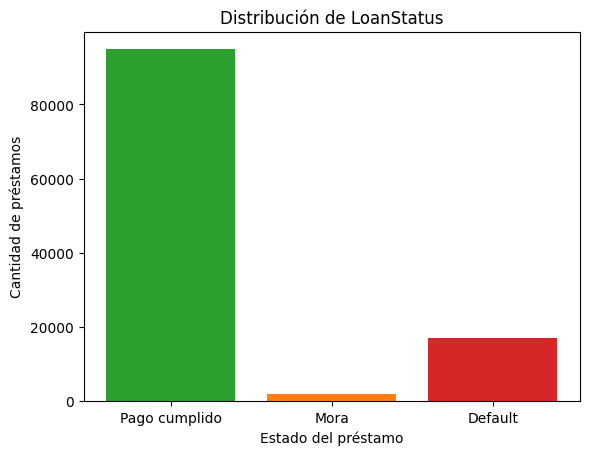

In [40]:
import matplotlib.pyplot as plt

# Conteo absoluto y proporcional
print(df["LoanStatus_num"].value_counts().sort_index())
print(df["LoanStatus_num"].value_counts(normalize=True).sort_index() * 100)

# Gráfico de barras (con etiquetas legibles en el eje x)
etiquetas = {0: "Pago cumplido", 1: "Mora", 2: "Default"}
conteo = df["LoanStatus_num"].value_counts().sort_index()

plt.bar(conteo.index.map(etiquetas), conteo.values, color=["#2ca02c", "#ff7f0e", "#d62728"])
plt.title("Distribución de LoanStatus")
plt.xlabel("Estado del préstamo")
plt.ylabel("Cantidad de préstamos")
plt.show()

Se evidencia un dataset desbalanceado, cómo resultado de la gran cantidad de clientes con pagos cumplidos. La variable objetivo muestra que el 83,25% de los clientes han pagado sus obligaciones de manera cumplida, a su vez, que el 14,93% se encuentra en default y en una menor proporción que el 1,81% de los prestatarios se encuentra en mora.

#Analisis exploratorio de los datos (EDA)

In [41]:
# Lista de variables numéricas reales (excluye IDs y el target)
numericas = [
    "Term", "ProsperRating (numeric)", "ProsperScore", "ListingCategory (numeric)",
    "EmploymentStatusDuration", "OpenCreditLines", "OpenRevolvingMonthlyPayment",
    "InquiriesLast6Months", "TotalInquiries", "CurrentDelinquencies", "AmountDelinquent",
    "DelinquenciesLast7Years", "PublicRecordsLast10Years", "PublicRecordsLast12Months",
    "RevolvingCreditBalance", "BankcardUtilization", "AvailableBankcardCredit",
    "TradesNeverDelinquent (percentage)", "TradesOpenedLast6Months", "DebtToIncomeRatio",
    "StatedMonthlyIncome", "TotalProsperLoans", "LoanOriginalAmount", "CreditScoreMid",
    "AntiguedadCrediticiaAnios"
]

# Estadísticas descriptivas
df[numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
Term,113932.0,40.830460,10.436392,12.0,36.000000,36.000000,36.000000,6.000000e+01
ProsperRating (numeric),113932.0,4.072243,1.443992,1.0,3.000000,4.072243,5.000000,7.000000e+00
ProsperScore,113932.0,5.950067,2.050917,1.0,5.000000,5.950067,7.000000,1.100000e+01
ListingCategory (numeric),113932.0,2.774322,3.996847,0.0,1.000000,1.000000,3.000000,2.000000e+01
EmploymentStatusDuration,113932.0,96.072162,91.266168,0.0,28.000000,74.000000,130.000000,7.550000e+02
OpenCreditLines,113932.0,9.260184,4.852249,0.0,6.000000,9.000000,12.000000,5.400000e+01
OpenRevolvingMonthlyPayment,113932.0,398.308649,447.162496,0.0,114.000000,271.000000,525.000000,1.498500e+04
InquiriesLast6Months,113932.0,1.435012,2.429887,0.0,0.000000,1.000000,2.000000,1.050000e+02
TotalInquiries,113932.0,5.584384,6.397295,0.0,2.000000,4.000000,7.000000,3.790000e+02
CurrentDelinquencies,113932.0,0.591968,1.972445,0.0,0.000000,0.000000,0.000000,8.300000e+01


# Análisis Histogramas, diagramas de barras y Box-plot

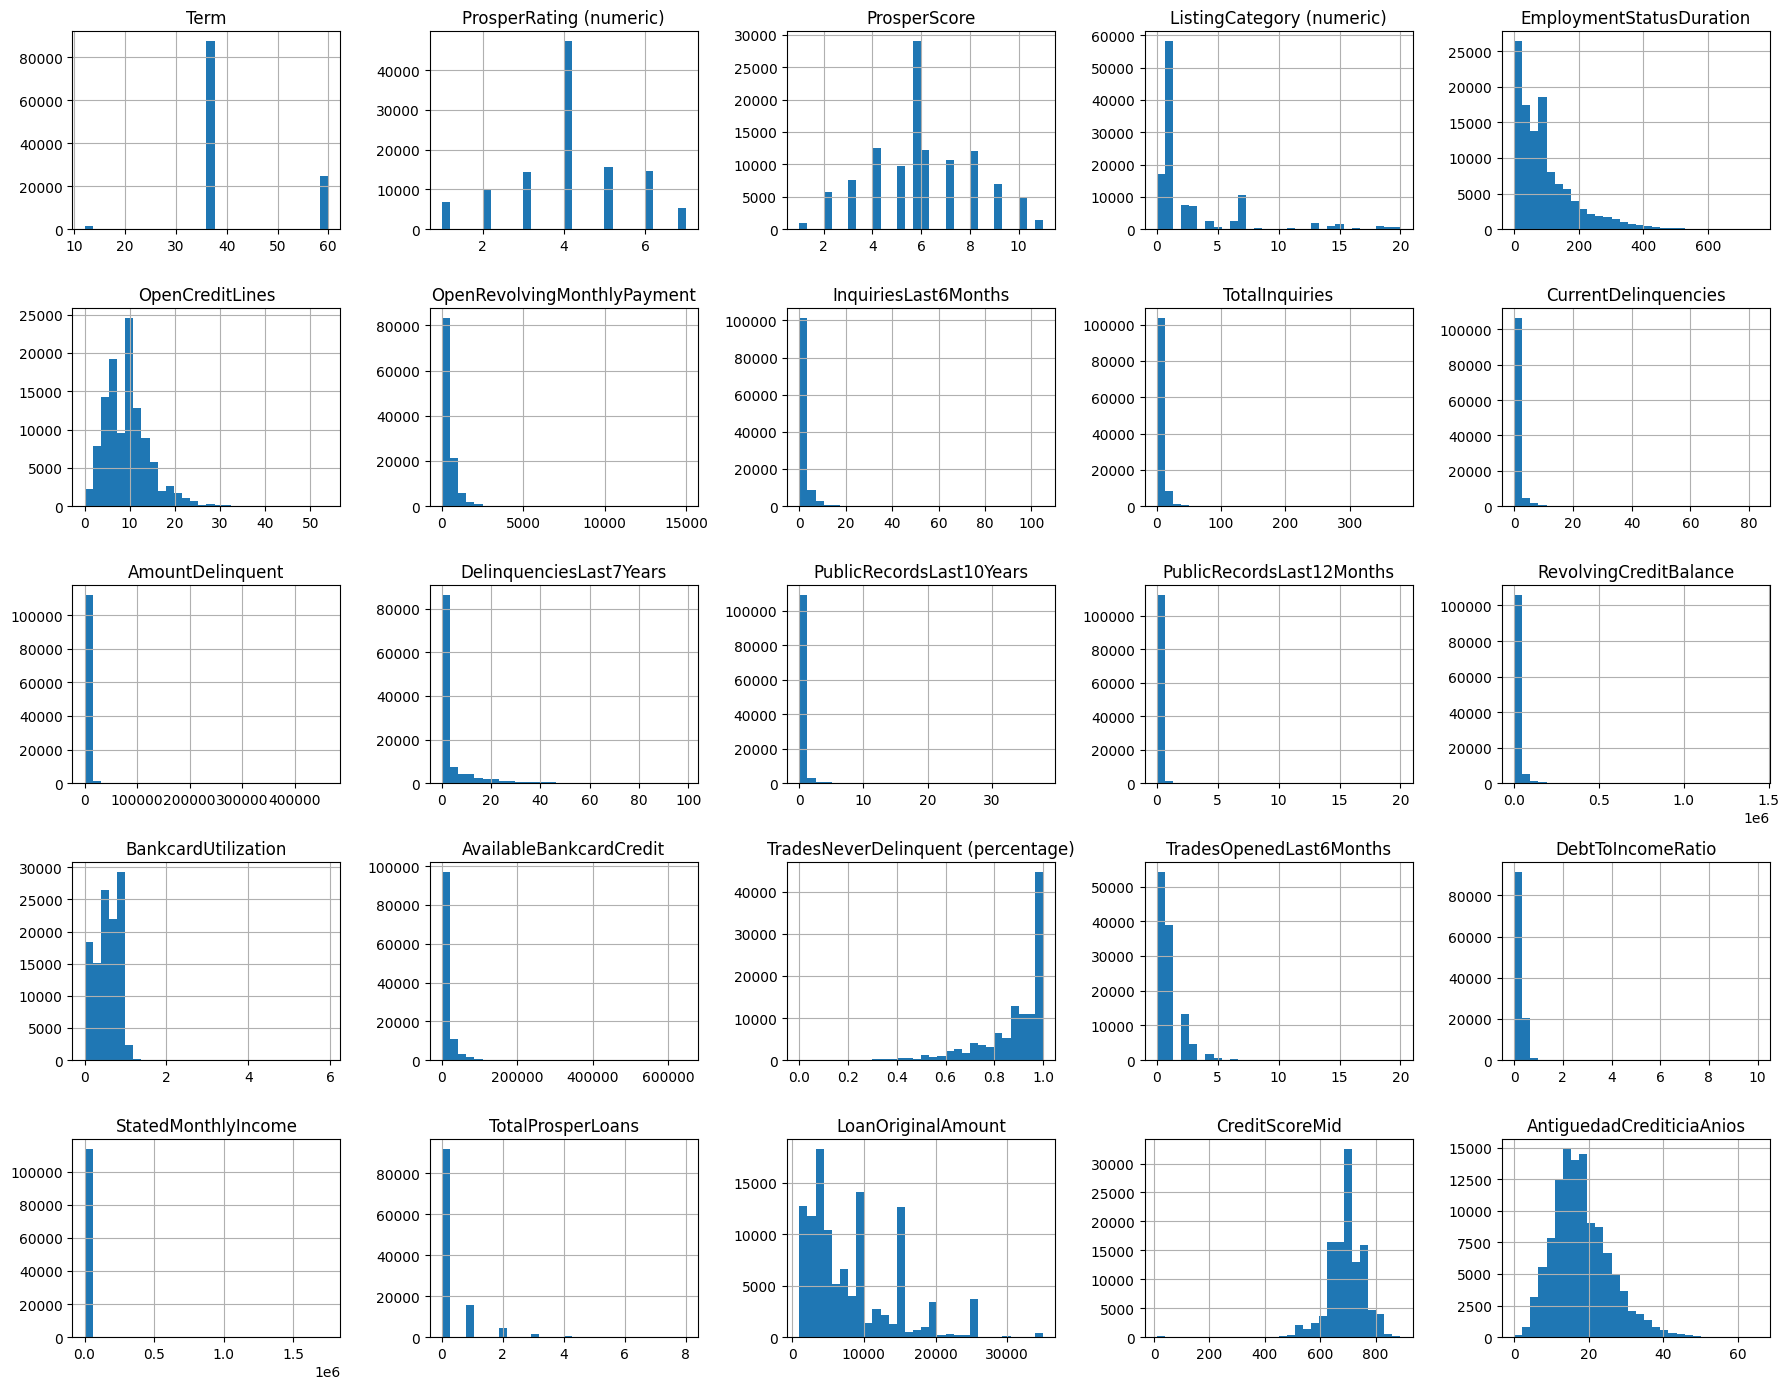

In [42]:
import matplotlib.pyplot as plt

# Histogramas de todas las numéricas en una sola figura
df[numericas].hist(bins=30, figsize=(18, 14))
plt.tight_layout()
plt.show()

Se evidencia que el plazo de préstamos se sitúa en 36 y 60 meses aproximadamente, la calificación de riesgo más frecuente es la 4 (un punto medio). A su vez se evidencia que la mayoría de préstamos tienen como objetivo consolidar deudas. Los clientes en su mayoría llevan poco tiempo en su trabajo, tienen entre 5 y 10 líneas de crédito y pagan relativamente poco mensualmente por estas. En cuanto al uso de tarjetas,la mayoría usan el 60% a 100%  del cupo de sus tarjetas. Se evidencia que recientemente los prestatarios no han tenido consultas de crédito, lo cual da como resultado que recientemente no se hayan abierto cuentas nuevas.

En cuanto a la morosidad, se evidencia que casi nadie se encuentra en mora y a su vez, que no se han presentado registros negativos en los últimos 12 meses, 7 años y 10 años. Esto es consecuente con que la mayoría tiene un % alto de cuentas sin mora, un porcentaje bajo de endeudamiento respecto a sus ingresos, a pesar de contar con ingresos moderados.

Por último, se evidencia que la mayoría no han tenido anteriormente créditos con Prosper y los montos solicitados se sitúan en cifras redondas (5k, 10k,15k,20k). Se destaca que la mayoría cuentan con un score crediticio alto, quizás cómo resultado de tener entre 10 y 20 años de historial crediticio.


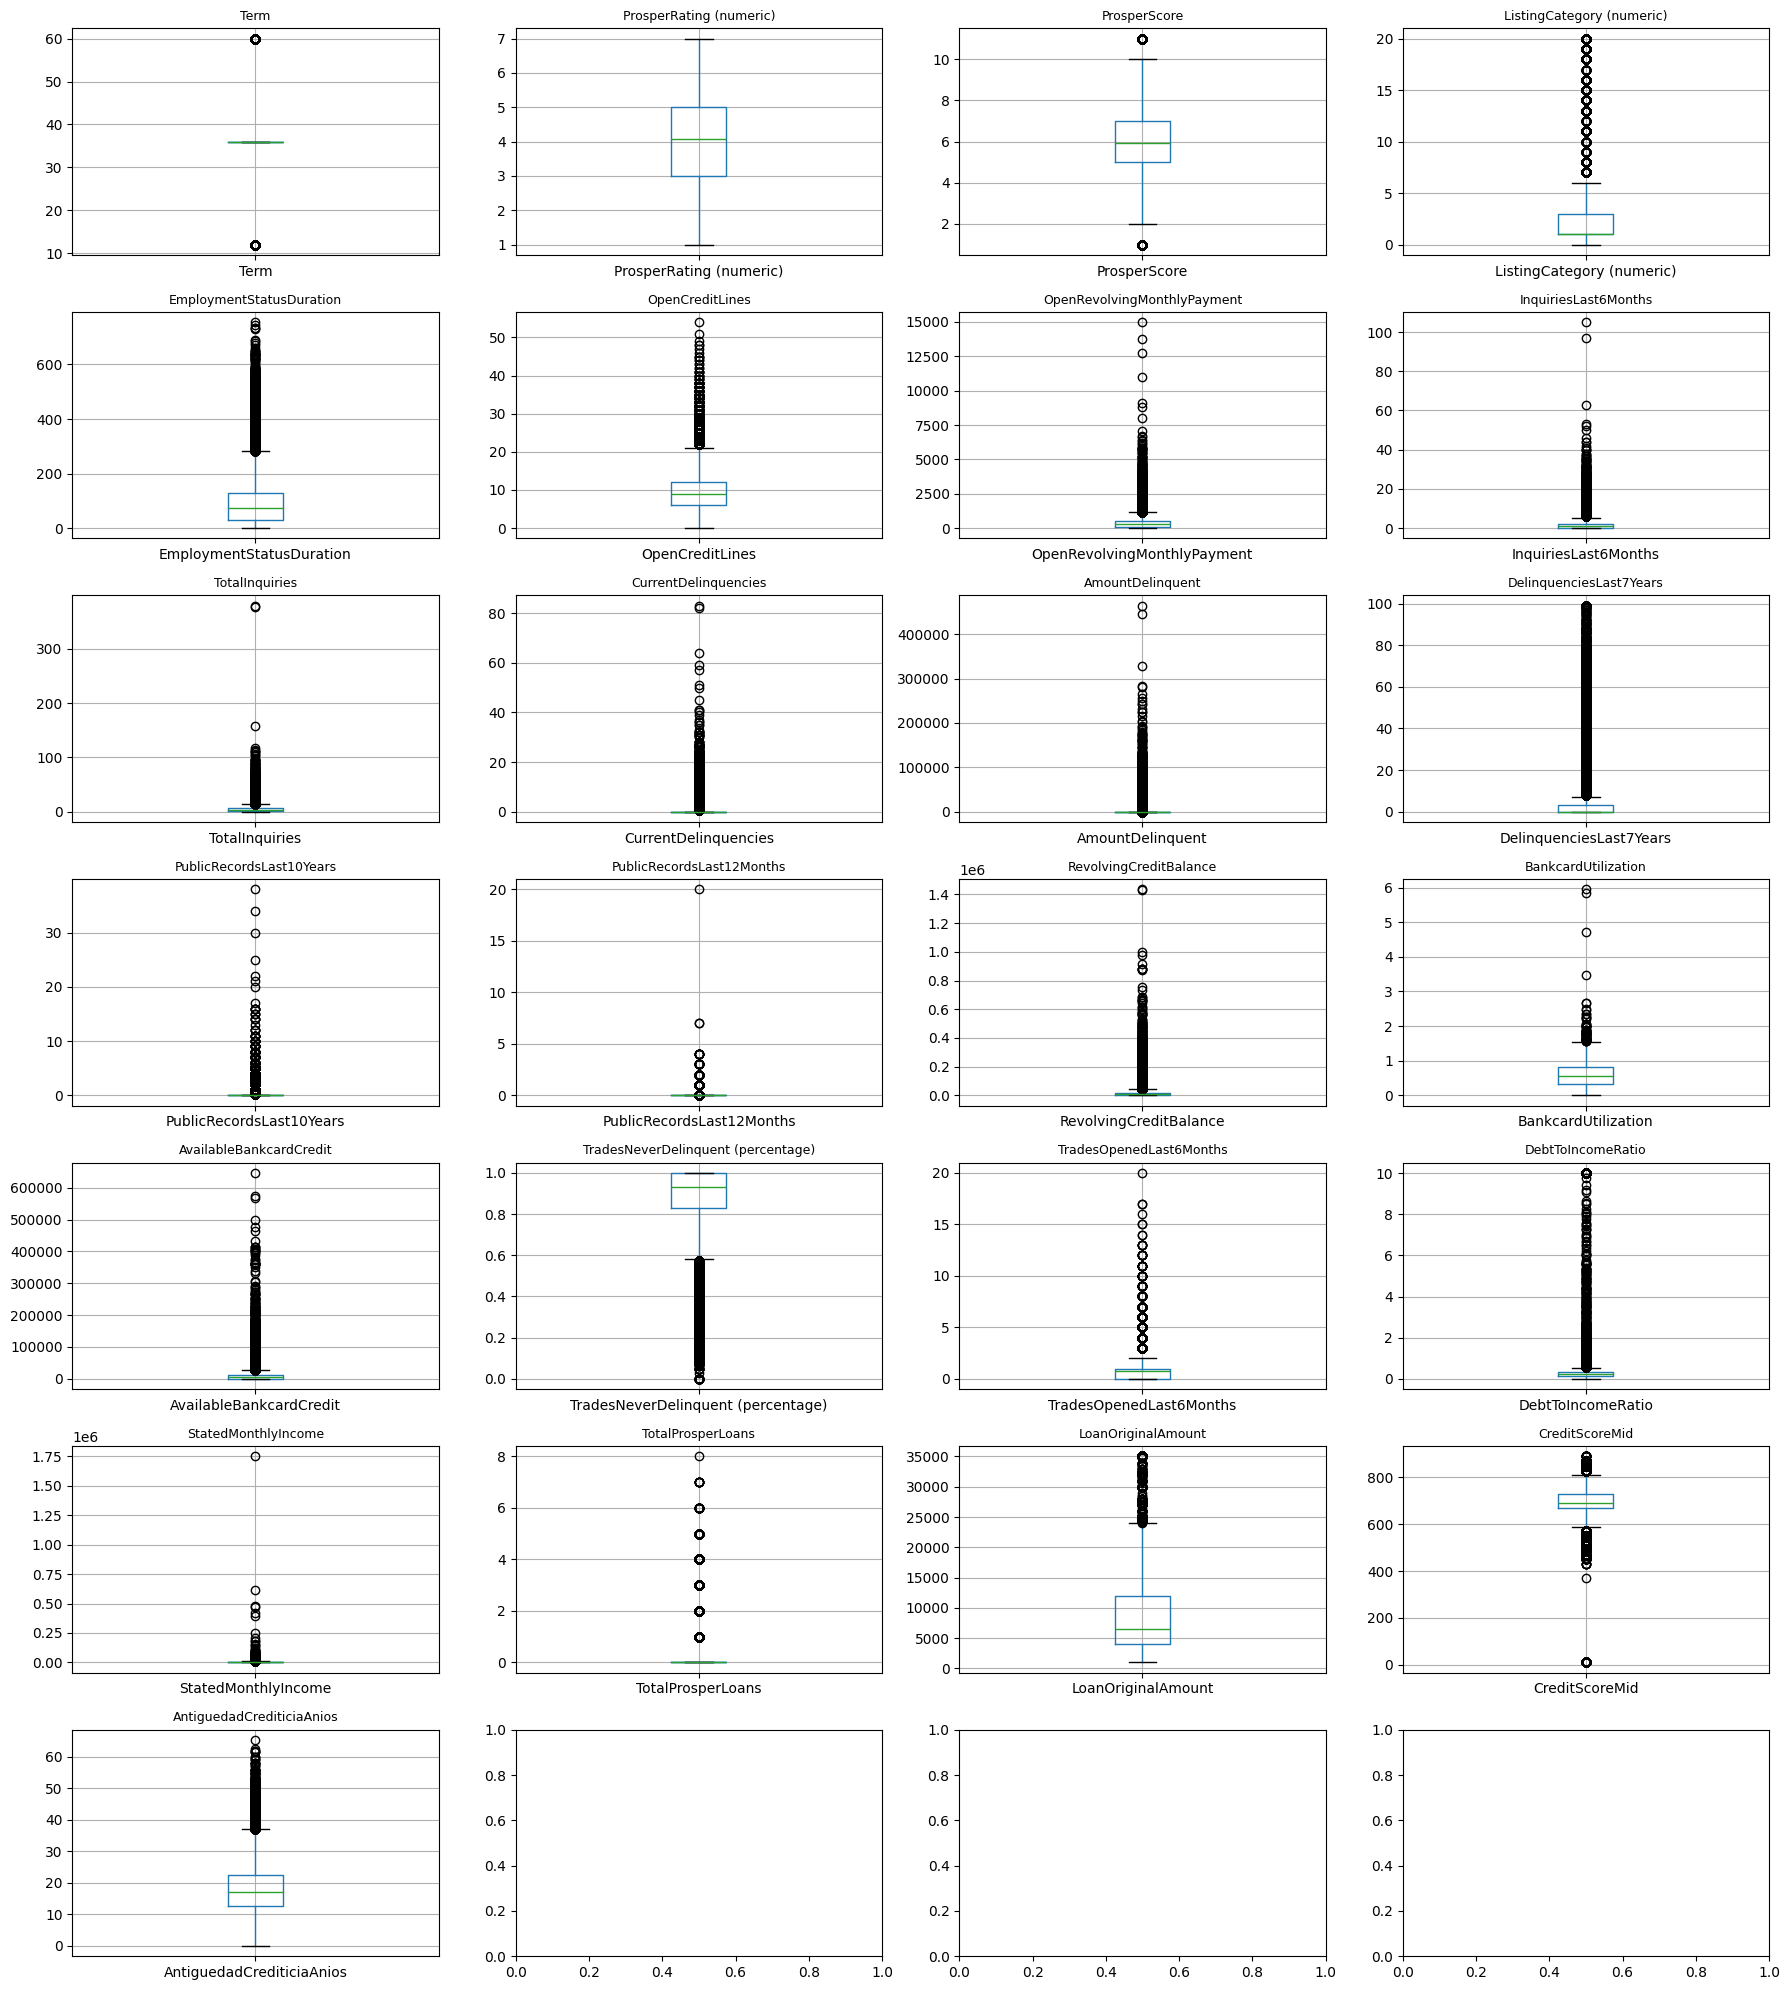

In [43]:
# Boxplots (mejor para detectar outliers de un vistazo)
fig, axes = plt.subplots(7, 4, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(numericas):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col, fontsize=9)

plt.tight_layout()
plt.show()

La gran mayoría de las variables numéricas muestran distribuciones fuertemente asimétricas hacia la derecha, con abundantes valores atípicos. Variables como: “EmploymentStatusDuration”, “OpenCreditLines”, “OpenRevolvingMonthlyPayment”, “InquiriesLast6Months”, “TotalInquiries”, “CurrentDelinquencies”, “AmountDelinquent”, “DelinquenciesLast7Years”, “PublicRecordsLast10Years”, “PublicRecordsLast12Months”, “RevolvingCreditBalance”,"AvailableBankcardCredit”, “TradesOpenedLast6Months”, “DebtToIncomeRatio”, “StatedMonthlyIncome” y “TotalProsperLoans” comparten este mismo patrón.

La caja se concentra muy cerca de cero y aparece una cola larga de outliers hacia valores altos. Esto es esperable en variables de comportamiento financiero, como ingresos, moras, consultas de crédito, cupos, etc;  donde la mayoría de los solicitantes tiene valores bajos o moderados y solo una minoría presenta cifras extremas.

Un segundo grupo de variables tiene distribuciones más simétricas y acotadas, con más pocos outliers extremos. Variables como: “ProsperRating (numeric)”, “ProsperScore”, “CreditScoreMid”, “AntiguedadCrediticiaAnios”, “BankcardUtilization” y “TradesNeverDelinquent (percentage)”, corresponden en su mayoría a scores y ratios ya normalizados internamente por Prosper, lo que explica su comportamiento más estable y su menor necesidad de tratamiento adicional.

Finalmente, “Term” y “ListingCategory (numeric)” se comportan como variables discretas o categóricas codificadas numéricamente más que como continuas. En el caso de Term, esta toma prácticamente solo tres valores (12, 36, 60 meses), y ListingCategory muestra saltos discretos típicos de un código categórico, no de una magnitud continua.


### Interpretación de las variables numéricas:



In [44]:
categoricas = [
    "CreditGrade", "ProsperRating (Alpha)", "BorrowerState", "Occupation",
    "EmploymentStatus", "IsBorrowerHomeowner", "CurrentlyInGroup",
    "IncomeRange", "IncomeVerifiable", "LoanOriginationQuarter", "Recommendations"
]

for col in categoricas:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(normalize=True).head(10) * 100)


--- CreditGrade ---
CreditGrade
C     79.549205
D      4.522873
B      3.852298
AA     3.079907
HR     3.076396
A      2.908753
E      2.886810
NC     0.123758
Name: proportion, dtype: float64

--- ProsperRating (Alpha) ---
ProsperRating (Alpha)
C     41.624829
B     13.675701
A     12.771653
D     12.528526
E      8.597233
HR     6.086964
AA     4.715093
Name: proportion, dtype: float64

--- BorrowerState ---
BorrowerState
CA    17.755328
TX     6.005337
NY     5.906155
FL     5.897377
IL     5.196960
GA     4.395604
OH     3.683776
MI     3.153636
VA     2.877155
NJ     2.718288
Name: proportion, dtype: float64

--- Occupation ---
Occupation
Other                       28.263350
Professional                11.961521
Computer Programmer          3.930415
Executive                    3.783836
Teacher                      3.299336
Administrative Assistant     3.236141
Analyst                      3.161535
Sales - Commission           3.024611
Accountant/CPA               2.837658
Cleri

En general, las variables categóricas presentan alta concentración en una o dos categorías dominantes, con una larga cola de categorías minoritarias.
“CreditGrade” y “ProsperRating (Alpha)” están dominadas por la categoría C, “EmploymentStatus” por Employed y por Full-time, “Occupation” por Other, y las variables “CurrentlyInGroup” y “Recommendations” son casi constantes, ya que se encuentran inmensamente concentrados en las categorías False y 0 respectivamente. Esto nos permite afirmar que estas variables aportarán un poder predictivo limitado si no se agrupan sus categorías minoritarias, y que Recommendations y CurrentlyInGroup, en particular, podrían tener utilidad marginal dado su casi nulo balance.

Otro grupo de variables muestra una mayor diversidad en sus categorías, pero con jerarquía clara. Inicialmente, “BorrowerState” está liderado por CA, TX, NY, FL; “IncomeRange” está concentrado en los rangos medios de 25,000 – 99,999; y “LoanOriginationQuarter” tiene un mayor peso en los trimestres recientes del dataset. Estas variables sí muestran variabilidad suficiente como para aportar información.

Por último, las variables binarias “IsBorrowerHomeowner” e “IncomeVerifiable” se comportan de forma distinta entre sí. La primera está bien balanceada, aproximadamente 50/50 entre propietarios y no propietarios; mientras que la segunda está fuertemente desbalanceada hacia True, es decir, ingresos verificables, lo cual es coherente con el proceso de originación de Prosper, que privilegia a los solicitantes con ingresos verificados.


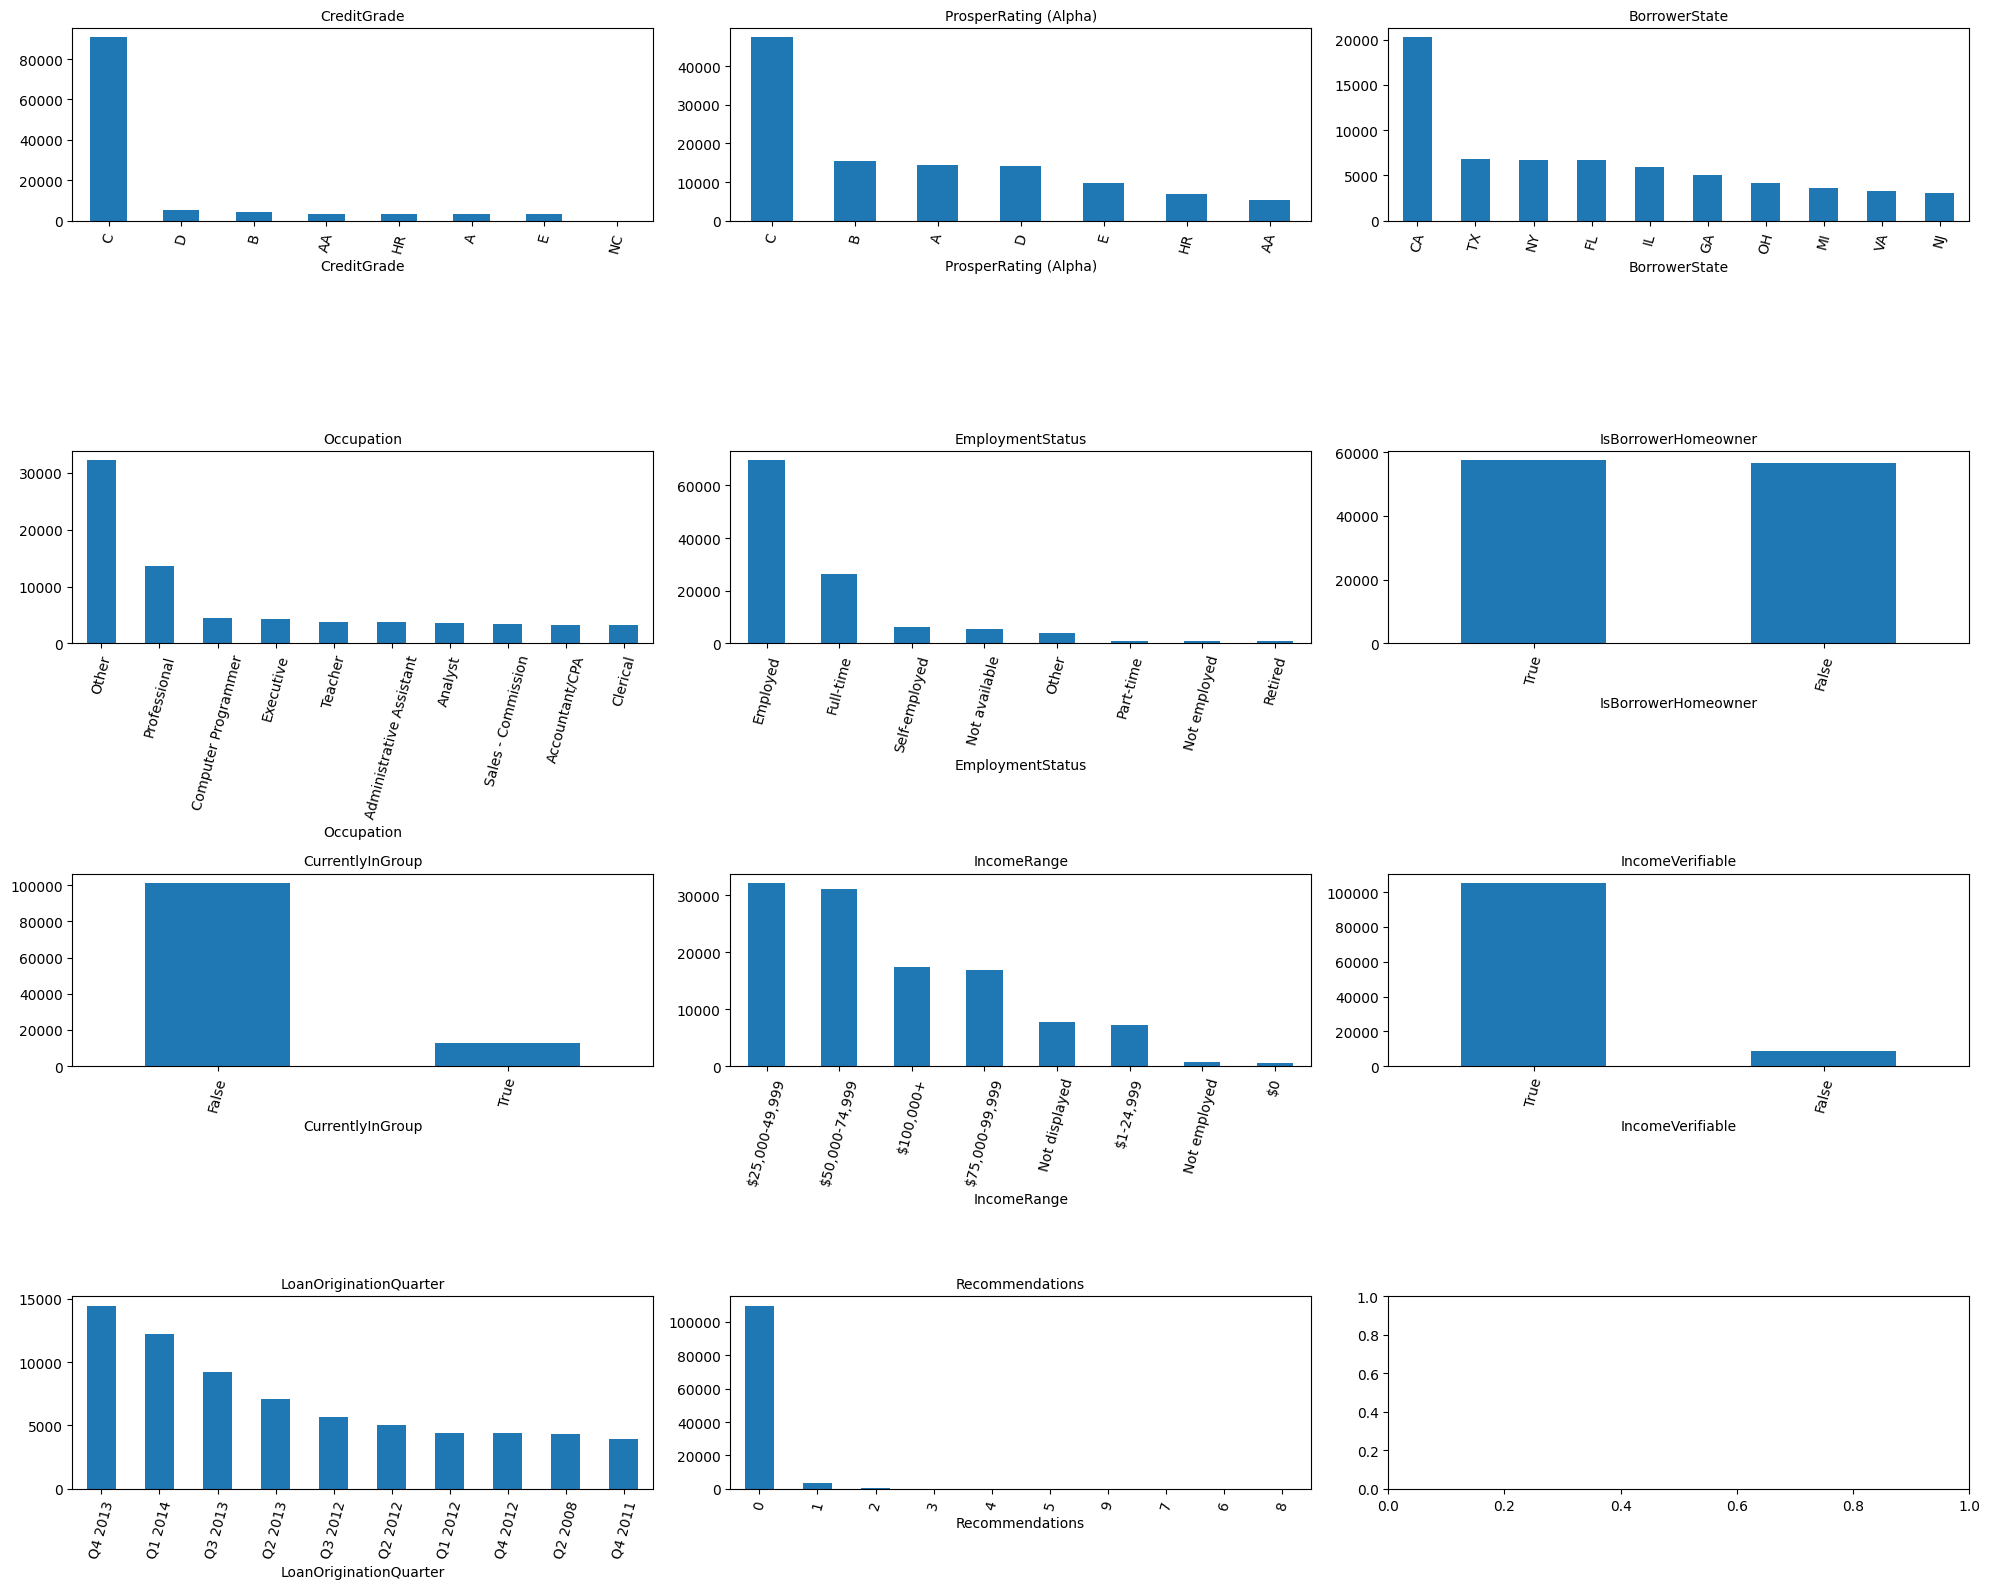

In [45]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 3, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(categoricas):
    top_categorias = df[col].value_counts().nlargest(10)  # top 10 si hay muchas
    top_categorias.plot(kind="bar", ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis='x', rotation=75)

plt.tight_layout()
plt.show()

#Matriz de correlaciones final

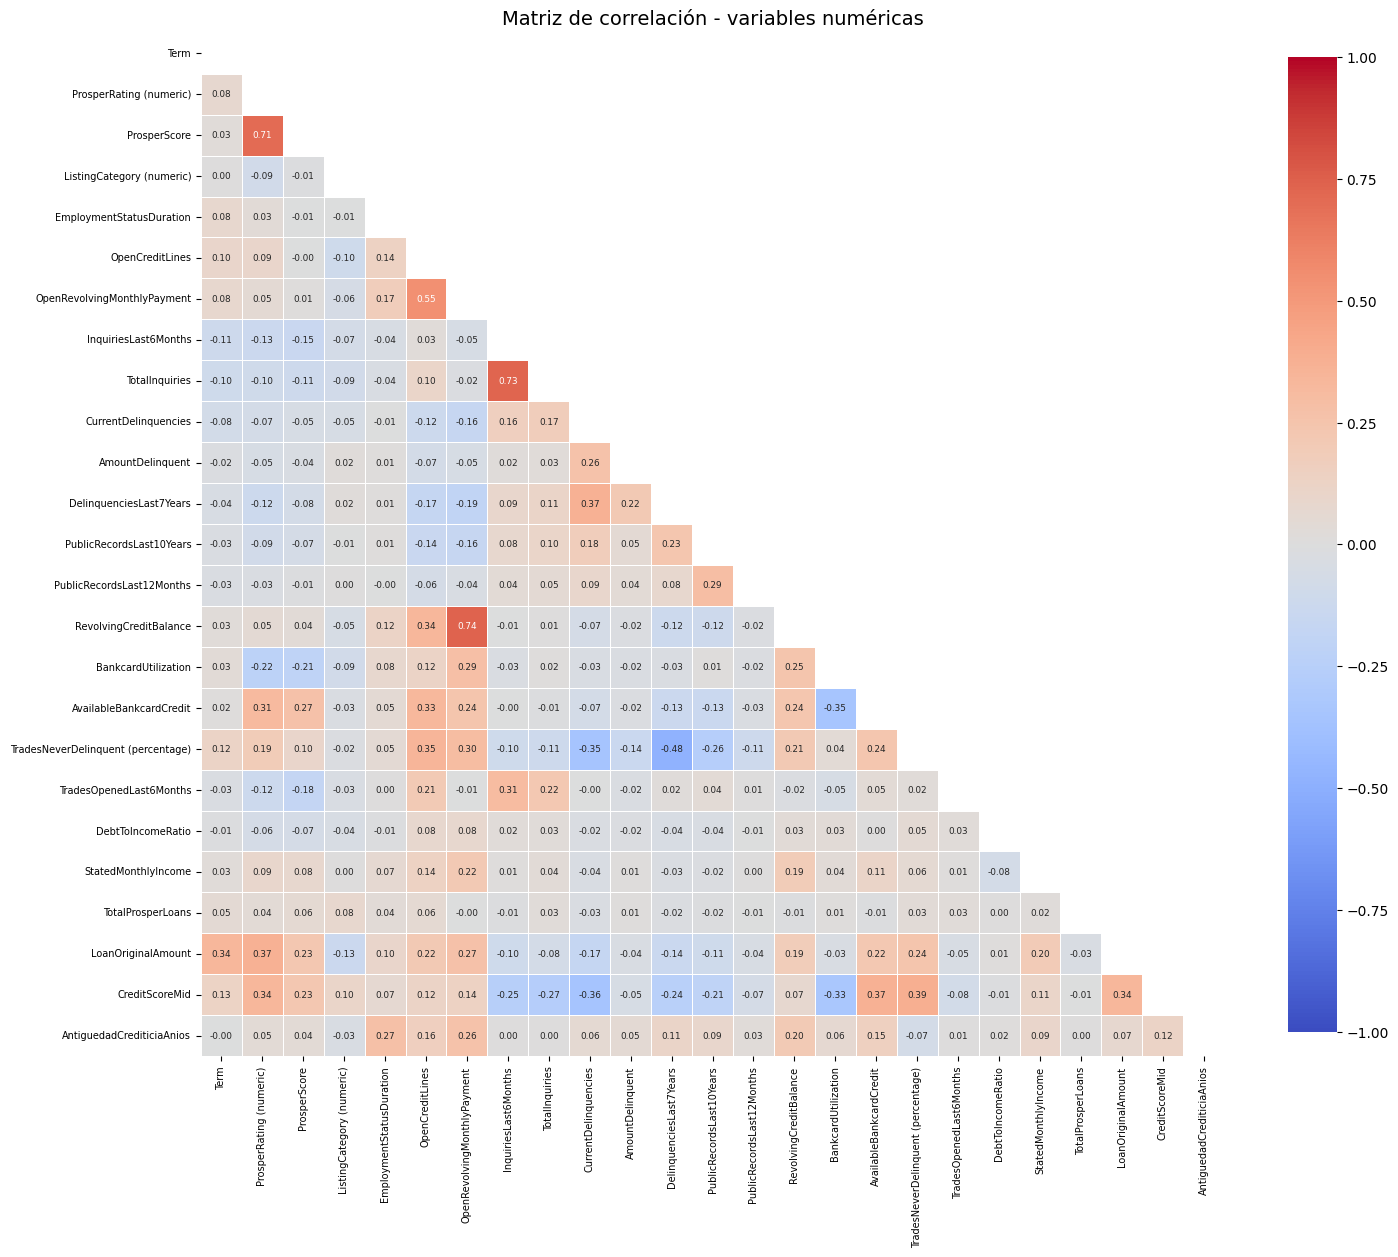

In [46]:
import seaborn as sns

# --- Matriz de correlación sobre las variables numéricas ---
corr = df[numericas].corr()

n = len(numericas)
mask = np.triu(np.ones_like(corr, dtype=bool))   # oculta la mitad superior (redundante)

plt.figure(figsize=(max(12, n * 0.6), max(10, n * 0.55)))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    annot=True, fmt=".2f",
    center=0, vmin=-1, vmax=1,          # escala fija -1 a 1 para colores consistentes
    linewidths=.5, square=True,
    annot_kws={"fontsize": max(5, 160 / n)},
    cbar_kws={"shrink": .8}
)
plt.title("Matriz de correlación - variables numéricas", fontsize=14)
plt.xticks(rotation=90, fontsize=max(7, 140 / n))
plt.yticks(rotation=0, fontsize=max(7, 140 / n))
plt.tight_layout()
plt.show()

Como se puede ver la mayoria de las variables tienen correlaciones bajas, lo que es muy positivo ya que ninguna de las variables está aportando información redundante, a excepcionde unas pocas variables que no llegan a una correlación fuerte, por lo que se considera que no deberian de eliminarse.

In [47]:
#Debido a que para el modelado se va a hacer la metodologia de transfotmacion OneHotEncoding en las variables categoricas,
#se analizaran las siguientes variables para reducir la alta cardinalidad:

df_model = df.copy()

#Eliminar variables redundantes / casi constantes
a_eliminar = [
    "ProsperRating (Alpha)",
    "CreditGrade",
    "Recommendations",
    "LoanOriginationQuarter",
]

df_model = df_model.drop(columns=a_eliminar)

#Se eliminará Recommendatiions, ProsperRating (Alpha) (Ya que es redundante con ProsperRating (Numeric)),
#CreditGrade viene de valores viejos antes de la crisis que no sirven para el analisis y fue fuertemente imputado con la moda y
#Finalmente LoanOriginationQuarter es una variable estacional que no aporta mucha información

#Agrupar categorías raras en las de alta cardinalidad
#Se conservam las categorícas frecuentes tal cual y colapsas todas las raras (Frecuencia de 1%) en "Otras"
def agrupar_raras(serie, min_frac=0.01, etiqueta="Otras"):
    frec = serie.value_counts(normalize=True)
    frecuentes = frec[frec >= min_frac].index
    return serie.where(serie.isin(frecuentes), etiqueta)

for c in ["BorrowerState", "Occupation"]:
    df_model[c] = agrupar_raras(df_model[c], min_frac=0.01)

#Redefinir las listas que consumirán los modelos
numericas = [
    "Term", "ProsperRating (numeric)", "ProsperScore", "ListingCategory (numeric)",
    "EmploymentStatusDuration", "OpenCreditLines", "OpenRevolvingMonthlyPayment",
    "InquiriesLast6Months", "TotalInquiries", "CurrentDelinquencies", "AmountDelinquent",
    "DelinquenciesLast7Years", "PublicRecordsLast10Years", "PublicRecordsLast12Months",
    "RevolvingCreditBalance", "BankcardUtilization", "AvailableBankcardCredit",
    "TradesNeverDelinquent (percentage)", "TradesOpenedLast6Months", "DebtToIncomeRatio",
    "StatedMonthlyIncome", "TotalProsperLoans", "LoanOriginalAmount", "CreditScoreMid",
    "AntiguedadCrediticiaAnios",
]

categoricas = [
    "BorrowerState", "Occupation", "EmploymentStatus",
    "IsBorrowerHomeowner", "IncomeRange", "IncomeVerifiable",
]

X = df_model[numericas + categoricas].copy()
X[categoricas] = X[categoricas].astype(str)

from sklearn.preprocessing import OneHotEncoder
prep_check = ColumnTransformer([
    ("num", StandardScaler(), numericas),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categoricas)
])


#Arboles de decisión



In [48]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

X = df_model[numericas + categoricas]
y = df_model["LoanStatus_num"]

print(X.shape, y.value_counts(normalize=True))

preprocesador = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numericas),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categoricas)
])

X_prep = preprocesador.fit_transform(X)
print("Dimensiones tras preprocesar:", X_prep.shape)


(113932, 31) LoanStatus_num
0    0.832558
2    0.149300
1    0.018142
Name: proportion, dtype: float64
Dimensiones tras preprocesar: (113932, 94)


#Stratiffied k-folds para arboles de decisión y el resto de modelos

In [49]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

Accuracy = np.zeros(10)
F1_macro = np.zeros(10)
j = 0

for train_index, test_index in skf.split(X_prep, y):
    X_train, X_test = X_prep[train_index], X_prep[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    arbol = DecisionTreeClassifier(max_depth=10, class_weight="balanced", random_state=42)
    arbol.fit(X_train, y_train)
    y_est = arbol.predict(X_test)

    Accuracy[j] = accuracy_score(y_test, y_est)
    F1_macro[j] = f1_score(y_test, y_est, average="macro")
    j += 1

print("\nResultados para el problema de clasificación con Árboles de Decisión\n")
print("Accuracy promedio:", np.mean(Accuracy))
print("F1-macro promedio:", np.mean(F1_macro))


Resultados para el problema de clasificación con Árboles de Decisión

Accuracy promedio: 0.502501455144593
F1-macro promedio: 0.39047087665904645


Arboles de decision con ajuste de hiperparametros

In [ ]:
malla_arbol = {
    "max_depth": [4, 6, 8, 10, None],
    "min_samples_leaf": [50, 200, 1000],
    "criterion": ["gini", "entropy"]
}

arbol_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(class_weight="balanced", random_state=42),
    param_grid=malla_arbol,
    scoring="f1_macro",
    cv=skf,
    n_jobs=-1
)

arbol_grid.fit(X_prep, y)

print("Mejores hiperparámetros:", arbol_grid.best_params_)
print("Mejor F1-macro (promedio en los 10 folds):", arbol_grid.best_score_)

Mejores hiperparámetros: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 50}
Mejor F1-macro (promedio en los 10 folds): 0.4098003718747364


Los árboles de decisión son modelos que resuelven problemas de regresión y clasificación, en este caso, solucionamos nuestro problema con árboles de decisión. Este árbol se encarga de realizar una selección de características y umbral a partir de la ganancia de información  y su predicción se realiza a partir de la moda.

Los hiperparámetros elegidos por la malla fueron:

-	max_depth=None:  la malla evidenció mejores resultados cuando al árbol no se le impuso un límite de profundidad, por lo que pudo crecer hasta donde las reglas siguieran siendo útiles. Esto evidencia que para relacionar las características de los prestatarios y su estatus de pago no se logra capturar en pocas divisiones, el modelo necesitó bastante profundidad para realizar una mejor separación de clases.
-	Criterion = entropy:  se toma como medida de impureza de un nodo específico el índice de entropía, en vez del índice de gini. Esta decisión no supone un cambio marginal muy grande, solo se evidenció un mejor desempeño
-	min_samples_leaf=50: cada nodo hoja debe tener al menos 50 solicitantes, evitando nodos con grupos de personas bastantes pequeños. Esto es relevante para evitar el sobreajuste y compensar el hecho de que no existiera límite de profundidad dado el fuerte desbalance que presentaba la clase de pago normal.

Se evidencia que la malla favoreció un árbol profundo pero regularizando el tamaño mínimo en los nodo hoja, priorizando la capacidad de capturar patrones complejos y no simples.
F1-macro (0.4098)
Al promediar por igual los F1 de las tres clases, obtenemos un valor de 0.41, que indica un desempeño moderado-bajo. Dado que el F1 macro no pondera por frecuencia, este resultado sugiere que el modelo tiene dificultades para predecir las clases minoritarias: mora y default, por lo que el bajo desempeño de estas arrastra el promedio para abajo.


#Bagging para arboles de decisión

In [ ]:
#Baseline
from sklearn.ensemble import BaggingClassifier

Accuracy = np.zeros(10)
F1_macro = np.zerosm(10)
j = 0

for train_index, test_index in skf.split(X_prep, y):
    X_train, X_test = X_prep[train_index], X_prep[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    bagging = BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=10, class_weight="balanced", random_state=42),
        n_estimators=20,
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    )
    bagging.fit(X_train, y_train)
    y_est = bagging.predict(X_test)

    Accuracy[j] = accuracy_score(y_test, y_est)
    F1_macro[j] = f1_score(y_test, y_est, average="macro")
    j += 1

print("\nResultados para Bagging con Árboles (sin ajuste de hiperparámetros)\n")
print("Accuracy promedio:", np.mean(Accuracy))
print("F1-macro promedio:", np.mean(F1_macro))

Bagging arboles de decision con ajuste de hiperparametros

In [57]:
malla_bagging = {
    "n_estimators": [30, 60],
    "max_samples": [0.5, 1.0],
    "estimator__max_depth": [5, 10],
    "estimator__min_samples_leaf": [50, 200],
}

from sklearn.ensemble import BaggingClassifier

bagging_arboles = BaggingClassifier(
    estimator=DecisionTreeClassifier(class_weight="balanced", random_state=42),
    bootstrap=True,
    random_state=42
)

bagging_grid = GridSearchCV(
    estimator=bagging_arboles,
    param_grid=malla_bagging,
    scoring="f1_macro",
    cv=skf,
    n_jobs=-1
)

bagging_grid = joblib.load('/content/drive/MyDrive/proyecto2_bagging_grid.pkl')
#bagging_grid.fit(X_prep, y)

print("Mejores hiperparámetros:", bagging_grid.best_params_)
print("Mejor F1-macro (CV):", bagging_grid.best_score_)

Mejores hiperparámetros: {'estimator__max_depth': 10, 'estimator__min_samples_leaf': 50, 'max_samples': 0.5, 'n_estimators': 60}
Mejor F1-macro (CV): 0.4287449755398332


Lo que hace Bagging es entrenar varios árboles de decisión sobre distintas muestras bootstrap de los solicitantes, y combina sus predicciones por voto mayoritario. Al promediar árboles entrenados con datos ligeramente distintos, se reduce la varianza y el riesgo de que un solo árbol sobreajuste patrones falsos de ingresos, score o historial crediticio, logrando una predicción más estable del estatus de pago.

Los hiperparámetros seleccionados por la malla fueron:

- n_estimators = 60: el modelo combina 60 árboles de decisión. Se prefirió el mayor número de árboles probado, lo que indica que más estimadores seguían aportando una mayor estabilidad al ensamble.
- max_samples = 0.5: cada árbol se entrena con solo el 50% de los datos, aumentando la diversidad entre árboles y reforzando el efecto de reducción de varianza propio de Bagging.
- max_depth = 10: cada árbol individual puede crecer hasta 10 niveles de profundidad, lo que permite capturar interacciones moderadamente complejas entre variables sin llegar a árboles demasiado profundos.
- min_samples_leaf = 50: obliga a que cada hoja tenga al menos 50 solicitantes, evitando reglas basadas en grupos muy pequeños, esto es esencial dado el desbalance hacia la clase de pago normal.
En definitiva, la malla favoreció árboles regularizados y diversos, agregados en buen número, como forma de controlar el sobreajuste típico de árboles individuales.

F1-macro (0.4287)

Al ponderar por igual las tres clases, un valor de 0.43 indica un desempeño moderado-bajo. El modelo probablemente clasifica razonablemente bien los pagos normales, pero tiene dificultad para distinguir mora y default, que son las clases minoritarias y de mayor interés para el negocio.


#Random forest para clasificación

Baseline

In [ ]:
from sklearn.ensemble import RandomForestClassifier

Accuracy = np.zeros(10)
F1_macro = np.zeros(10)
j = 0

for train_index, test_index in skf.split(X_prep, y):
    X_train, X_test = X_prep[train_index], X_prep[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    rf = RandomForestClassifier(
        n_estimators=150,
        max_depth=12,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    y_est = rf.predict(X_test)

    Accuracy[j] = accuracy_score(y_test, y_est)
    F1_macro[j] = f1_score(y_test, y_est, average="macro")
    j += 1

print("\nResultados para Random Forest (sin ajuste de hiperparámetros)\n")
print("Accuracy promedio:", np.mean(Accuracy))
print("F1-macro promedio:", np.mean(F1_macro))

Random forest con ajuste de hiperparametros

In [59]:
from sklearn.ensemble import RandomForestClassifier

malla_rf = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "max_features": ["sqrt", 0.5],
    "min_samples_leaf": [1, 50],
}

rf_base = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=1        # ojo: n_jobs=1 aquí, se paraleliza afuera
)

rf_grid = GridSearchCV(
    estimator=rf_base,
    param_grid=malla_rf,
    scoring="f1_macro",
    cv=skf,
    n_jobs=-1       # el paralelismo va en un solo nivel
)

rf_grid = joblib.load('/content/drive/MyDrive/proyecto2_rf_grid.pkl')
#rf_grid.fit(X_prep, y)


print("Mejores hiperparámetros:", rf_grid.best_params_)
print("Mejor F1-macro (CV):", rf_grid.best_score_)

Mejores hiperparámetros: {'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 100}
Mejor F1-macro (CV): 0.47156988001670197


Random Forest es un modelo de ensamble que entrena múltiples árboles sobre distintas muestras de bootstrap de los solicitantes. En dónde toma una muestra bootstrap  y entrena un árbol sobre esa muestra y en cada split selecciona una característica aleatoria de las totales.

Los hiperparámetros elegidos por la malla fueron:

-	n_estimators=100: el bosque está conformado por 100 árboles de decisión distintos, cada árbol se encargará de votar por una clase (pago cumplido, mora, default), y la predicción será la que más votos tenga. Un mayor número de árboles genera predicciones más acertadas pero tiene un costo de cómputo mayor.
- max_depth=20: en este caso el árbol tiene un límite de crecimiento, es decir, no lo deja crecer de forma descontrolada. En este caso serían 20 preguntas seguidas que el árbol podría hacer para dar una respuesta.
-	max_features=0.5: en cada división, cada árbol solo podrá considerar el 50% de las características disponibles escogidas al azar. Esto permite que los árboles no terminen usando las mismas variables y ayuda a que cada árbol se centre en cosas distintas.
-	min_samples_leaf=1: cada nodo hoja podría tener 1 solo solicitante. Este dato es relevante y comparable, puesto que al ser 100 árboles el sobreajuste de ese árbol no se repite en los otros 99 árboles (al ser entrenados con características y datos distintos).
Esta malla y este tipo de modelo, favoreció árboles individuales más libres como resultado de la mezcla de muchos árboles distintos entre sí, esto permitió que no se presentara sobreajuste.

F1-macro (0.4716)

Al promediar por igual los F1 de las tres clases obtenemos un valor de 0.47. Se evidencia una mejora relevante respecto a los otros modelos. Esto es coherente con la teoría de Random Forest que combina dos mecanismos para evitar el sobreajuste: muestras bootstrap para cada árbol y la selección aleatoria de características en cada división, mostrándolo como un modelo más robusto. Sin embargo, el resultado sigue mostrando un desempeño moderado como resultado del desbalance extremo en el data set.


In [ ]:
mejor_rf = rf_grid.best_estimator_
nombres = preprocesador.get_feature_names_out()
importancias = mejor_rf.feature_importances_

idx = np.argsort(importancias)[::-1][:10]

plt.figure(figsize=(8, 4))
plt.bar(np.arange(len(idx)), importancias[idx])
plt.xticks(np.arange(len(idx)), [nombres[i] for i in idx], rotation=45, ha="right")
plt.title("Top 10 variables más importantes - Random Forest")
plt.tight_layout()
plt.show

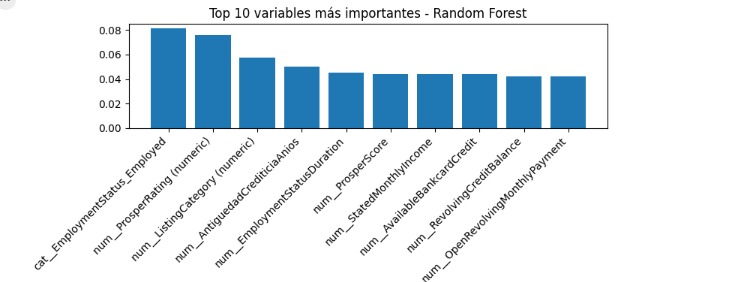

#Adaboost para clasificación

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

Accuracy = np.zeros(10)
F1_macro = np.zeros(10)
j = 0

for train_index, test_index in skf.split(X_prep, y):
    X_train, X_test = X_prep[train_index], X_prep[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1), #Ojo, este arbol no usa class weight
        n_estimators=100,
        learning_rate=0.5,
        random_state=42
    )
    ada.fit(X_train, y_train)
    y_est = ada.predict(X_test)

    Accuracy[j] = accuracy_score(y_test, y_est)
    F1_macro[j] = f1_score(y_test, y_est, average="macro")
    j += 1

print("\nResultados para AdaBoost (sin ajuste de hiperparámetros)\n")
print("Accuracy promedio:", np.mean(Accuracy))
print("F1-macro promedio:", np.mean(F1_macro))


Resultados para AdaBoost (sin ajuste de hiperparámetros)

Accuracy promedio: 0.83478738326508
F1-macro promedio: 0.40520595373095103


Adaboost con ajuste de hiperparametros

In [ ]:
malla_ada = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.5, 1.0],
    "estimator__max_depth": [1, 2],
}

ada_base = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(), #Ojo, este arbol no usa class weight
    random_state=42
)

ada_grid = GridSearchCV(
    estimator=ada_base,
    param_grid=malla_ada,
    scoring="f1_macro",
    cv=skf,
    n_jobs=-1
)

ada_grid.fit(X_prep, y)

print("Mejores hiperparámetros:", ada_grid.best_params_)
print("Mejor F1-macro (CV):", ada_grid.best_score_)

Mejores hiperparámetros: {'estimator__max_depth': 2, 'learning_rate': 0.5, 'n_estimators': 300}
Mejor F1-macro (CV): 0.4222248598572307


La búsqueda en malla seleccionó árboles base de profundidad 2 (estimator__max_depth=2), 300 estimadores (n_estimators=300) y una tasa de aprendizaje intermedia (learning_rate=0.5), alcanzando un F1-macro de 0.42 en validación cruzada. AdaBoost combina muchos clasificadores débiles, por lo que favorece árboles poco profundos (profundidad 2, apenas por encima de un stump) pero por lo mismo hace una cantidad elevada de ellos (300), para compensar la debilidad y tener un buen desempeño. la tasa de aprendizaje intermedia modera la contribución de cada árbol, evitando que el ensamble se sobreajuste al dar pasos demasiado grandes.

En AdaBoost no se usó class_weight="balanced": combinado con árboles poco profundos, el reponderado de la clase minoritaria hacía caer los clasificadores base por debajo del azar e impedía entrenar el modelo de forma correcta, (Aparecia un error que decia que el siguiente modelo estaba siendo peor que el anterior), por lo que el desbalance se dejó al reponderado iterativo propio de AdaBoost.

#XGboost para clasificación

Baseline

In [ ]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

Accuracy = np.zeros(10)
F1_macro = np.zeros(10)
j = 0

for train_index, test_index in skf.split(X_prep, y):
    X_train, X_test = X_prep[train_index], X_prep[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # pesos balanceados sobre la porción de entrenamiento de este fold
    sample_weight = compute_sample_weight("balanced", y_train)

    xgbc = XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="mlogloss", #Versión multiclase de logloss
        random_state=42,
        n_jobs=-1
    )
    xgbc.fit(X_train, y_train, sample_weight=sample_weight)
    y_est = xgbc.predict(X_test)

    Accuracy[j] = accuracy_score(y_test, y_est)
    F1_macro[j] = f1_score(y_test, y_est, average="macro")
    j += 1

print("\nResultados para XGBoost (sin ajuste de hiperparámetros)\n")
print("Accuracy promedio:", np.mean(Accuracy))
print("F1-macro promedio:", np.mean(F1_macro))


Resultados para XGBoost (sin ajuste de hiperparámetros)

Accuracy promedio: 0.5443773419377256
F1-macro promedio: 0.41636067132670557


XGboost con ajuste de hiperparametros

In [ ]:
malla_xgb = {
    "n_estimators": [200, 400],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
}

sample_weight_full = compute_sample_weight("balanced", y)

xgb_base = XGBClassifier(
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=1        # se paraleliza afuera, en el GridSearchCV
)

xgb_grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=malla_xgb,
    scoring="f1_macro",
    cv=skf,
    n_jobs=-1
)

xgb_grid.fit(X_prep, y, sample_weight=sample_weight_full)

print("Mejores hiperparámetros:", xgb_grid.best_params_)
print("Mejor F1-macro (CV):", xgb_grid.best_score_)

Mejores hiperparámetros: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 400, 'subsample': 0.8}
Mejor F1-macro (CV): 0.4595415815216784


La búsqueda en malla seleccionó max_depth=5, n_estimators=400, learning_rate=0.1 y subsample=0.8, alcanzando un F1-macro de 0.460 en validación cruzada. La configuración es coherente con el funcionamiento del gradient boosting: a diferencia de AdaBoost, XGBoost admite árboles base más profundos (max_depth=5), que capturan interacciones entre variables sin sobreajustar gracias a que el learning_rate=0.1 hace que cada árbol corrija el error de forma conservadora, encadenando muchos de ellos (n_estimators=400) para converger. El subsample=0.8 entrena cada árbol sobre el 80% de las filas, introduciendo aleatoriedad que reduce la varianza y mejora la generalización. Para el desbalance no se usó class_weight en su lugar se ponderaron las muestras con compute_sample_weight("balanced"), dando más peso a las clases minoritarias sin romper el algoritmo como ocurría en AdaBoost.

La diferencia de XGboost con otros modelos    es minima, esto demuestra que hay un techo impuesto por el problema multiclase, donde la clase "Mora" (~1.8%) resulta casi imposible de separar de "Default".

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import joblib

joblib.dump(arbol_grid, '/content/drive/MyDrive/proyecto2_arbol_grid.pkl')
joblib.dump(bagging_grid, '/content/drive/MyDrive/proyecto2_bagging_grid.pkl')
joblib.dump(rf_grid, '/content/drive/MyDrive/proyecto2_rf_grid.pkl')
joblib.dump(ada_grid, '/content/drive/MyDrive/proyecto2_ada_grid.pkl')
joblib.dump(xgb_grid, '/content/drive/MyDrive/proyecto2_xgb_grid.pkl')


print("Guardado OK")

Guardado OK


In [9]:
import joblib

arbol_grid = joblib.load('/content/drive/MyDrive/proyecto2_arbol_grid.pkl')
bagging_grid = joblib.load('/content/drive/MyDrive/proyecto2_bagging_grid.pkl')
rf_grid = joblib.load('/content/drive/MyDrive/proyecto2_rf_grid.pkl')
ada_grid = joblib.load('/content/drive/MyDrive/proyecto2_ada_grid.pkl')
xgb_grid = joblib.load('/content/drive/MyDrive/proyecto2_xgb_grid.pkl')

#Resultados de cada uno de los modelos
print("\nResultados para el problema de clasificación con Árboles de Decisión\n")
print(arbol_grid.best_params_)
print(arbol_grid.best_score_)
print("\nResultados para Bagging con Árboles\n")
print(bagging_grid.best_params_)
print(bagging_grid.best_score_)
print("\nResultados para Random Forest\n")
print(rf_grid.best_params_)
print(rf_grid.best_score_)
print("\nResultados para AdaBoost\n")
print(ada_grid.best_params_)
print(ada_grid.best_score_)
print("\nResultados para XGBoost\n")
print(xgb_grid.best_params_)
print(xgb_grid.best_score_)



Resultados para el problema de clasificación con Árboles de Decisión

{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 50}
0.4098003718747364

Resultados para Bagging con Árboles

{'estimator__max_depth': 10, 'estimator__min_samples_leaf': 50, 'max_samples': 0.5, 'n_estimators': 60}
0.4287449755398332

Resultados para Random Forest

{'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 100}
0.47156988001670197

Resultados para AdaBoost

{'estimator__max_depth': 2, 'learning_rate': 0.5, 'n_estimators': 300}
0.4222248598572307

Resultados para XGBoost

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 400, 'subsample': 0.8}
0.4595415815216784


In [ ]:
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_predict
mejor_modelo = rf_grid.best_estimator_
y_pred_cv = cross_val_predict(mejor_modelo, X_prep, y, cv=skf)
print(classification_report(y, y_pred_cv, target_names=["Pago cumplido", "Mora", "Default"]))

               precision    recall  f1-score   support

Pago cumplido       0.89      0.92      0.90     94855
         Mora       0.15      0.01      0.02      2067
      Default       0.51      0.47      0.49     17010

     accuracy                           0.83    113932
    macro avg       0.52      0.47      0.47    113932
 weighted avg       0.82      0.83      0.83    113932



Después de correr todos los modelos con todas las técnicas de ensamblaje, logramos evidenciar que el Macro-F1 se mantenía en niveles moderados-bajos para prácticamente todos los casos, por lo que entramos a evaluar las métricas de cada categoría a partir de un Classification Report.

Al revisar el reporte del mejor modelo, vimos que el problema no era que fallara en todo, sino que casi nunca acertaba en la clase "Mora", este tenía un F1 = 0.02, mientras que en "Pago cumplido" F1=0.90 y "Default" F1=0.49; es decir, sí tenían un desempeño más razonable. Como el F1-macro promedia las tres clases por igual, esa sola clase mal predicha bajaba mucho el promedio general.
“Mora” es una categoría muy pequeña, que representa aproximadamente el 1.8% de los casos (2,067 de 113,932 observaciones), y con tan pocos ejemplos el modelo casi nunca la reconoce. Por eso decidimos unir "Mora" y "Default" en una sola categoría, "impago", y dejar el problema como binario: paga vs. no paga.
Esta decisión tiene sentido por dos razones:

→ Inicialmente, para el negocio, lo que realmente importa al momento de dar el préstamo es si la persona va a pagar o no; distinguir entre dos formas distintas de no pagar no cambia mucho la decisión de crédito.
→ Además, para el modelo, al unir las dos categorías de no pago, la nueva clase "impago" tiene más ejemplos, lo que le da al modelo más información para aprender a reconocerla.



#Analisis del problema multiclase, comparacón con otro enfoque

Problema           Multiclase   Binario
Modelo                                 
Random Forest        0.471570  0.686464
XGBoost              0.459542  0.674026
Bagging (Árboles)    0.428745  0.653170
Árbol de Decisión    0.409800  0.650738
AdaBoost             0.422225  0.630527


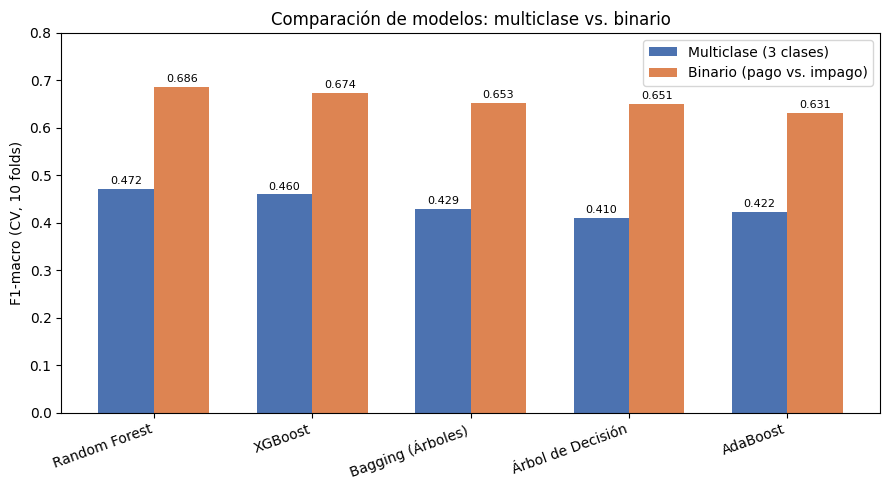

In [4]:
resultados_manual = pd.DataFrame([
    # --- Multiclase (3 clases) — objetos disponibles vía joblib, esta es tu entrega "oficial" ---
    {"Problema": "Multiclase", "Modelo": "Árbol de Decisión", "F1_macro_CV": 0.409800},
    {"Problema": "Multiclase", "Modelo": "Bagging (Árboles)", "F1_macro_CV": 0.428745},
    {"Problema": "Multiclase", "Modelo": "Random Forest",     "F1_macro_CV": 0.471570},
    {"Problema": "Multiclase", "Modelo": "AdaBoost",          "F1_macro_CV": 0.422225},
    {"Problema": "Multiclase", "Modelo": "XGBoost",           "F1_macro_CV": 0.459542},
    # --- Binario (pago vs. impago) — experimento adicional, transcrito manualmente ---
    {"Problema": "Binario",    "Modelo": "Árbol de Decisión", "F1_macro_CV": 0.650738},
    {"Problema": "Binario",    "Modelo": "Bagging (Árboles)", "F1_macro_CV": 0.653170},
    {"Problema": "Binario",    "Modelo": "Random Forest",     "F1_macro_CV": 0.686464},
    {"Problema": "Binario",    "Modelo": "AdaBoost",          "F1_macro_CV": 0.630527},
    {"Problema": "Binario",    "Modelo": "XGBoost",           "F1_macro_CV": 0.674026},
])

tabla_comparativa = resultados_manual.pivot(index="Modelo", columns="Problema", values="F1_macro_CV")
tabla_comparativa = tabla_comparativa[["Multiclase", "Binario"]].sort_values("Binario", ascending=False)
print(tabla_comparativa)

import matplotlib.pyplot as plt
import numpy as np

modelos = tabla_comparativa.index.tolist()
x = np.arange(len(modelos))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, tabla_comparativa["Multiclase"], w, label="Multiclase (3 clases)", color="#4C72B0")
b2 = ax.bar(x + w/2, tabla_comparativa["Binario"], w, label="Binario (pago vs. impago)", color="#DD8452")

ax.set_xticks(x)
ax.set_xticklabels(modelos, rotation=20, ha="right")
ax.set_ylabel("F1-macro (CV, 10 folds)")
ax.set_title("Comparación de modelos: multiclase vs. binario")
ax.bar_label(b1, fmt="%.3f", fontsize=8, padding=2)
ax.bar_label(b2, fmt="%.3f", fontsize=8, padding=2)
ax.legend()
ax.set_ylim(0, 0.8)
plt.tight_layout()
plt.show()

#Conclusiones finales

Conclusión 1: Random Forest fue el modelo con mejor desempeño (F1-macro de 0.47 en la formulación multiclase), gracias a que combina la variedad de datos con la variedad de variables entre sus árboles. Su principal desventaja es que requiere más cómputo que un árbol individual o que AdaBoost.

Conclusión 2: El desempeño moderado-bajo de los cinco modelos se explica en gran parte por el fuerte desbalance del dataset: con apenas 1.81% de los casos en la clase Mora, a los modelos les resulta difícil aprender a identificarla bien.

Conclusión 3: Con un dataset más balanceado, sería posible construir modelos más confiables que ayuden a los bancos a anticipar si un solicitante pagará su préstamo, entrará en mora o caerá en default antes de aprobar el crédito.

Conclusión 4: Al reducir el problema a solo dos clases (Pago cumplido e Impago, agrupando Mora y Default), los F1 mejoraron sustancialmente frente al modelo con tres clases. Esto confirma que buena parte de la dificultad venía del desbalance y de la fuerte similitud entre Mora y Default, que el modelo confundía constantemente entre sí.